# CNN PureMath: Part 3 of the PureMath series

In this notebook, I have created a convolutional neural network using cupy. a lot of the math involving the concepts is discussed here but obviously not all of it, again to reiterate from my earlier notebook, this notebook is more of a journal and is an accumulation of everything that I have learnt in the fields of math, ai theory and programming, and it may contain errors. Matter of fact, it is really easy to see the progression of my ideas from the initial part of the notebook right down to the final phase. I have tried to write most of the things I have learnt throughtout the journey of creating the CNN down in this notebook and the other book dedicated for the optimizer idea I had `CurveAndGradientBasedOptimizer`.

A lot of the code is made with help from LLMs such as chatgpt, but the ideas are all originally mine and I have tried to restrict myself on the usage of AI in order to develop the intuition required to program such complex algorithms.
for functions such as convolution and maxpool, I have relied on AI but I have still tried to code it out by myself.

This notebook uses cupy as an alternative for numpy, hence to run the notebook for yourself, you need to connect to a GPU, if you run on colab make sure to change the runtime type to GPU

I had to migrate to kaggle in the middle of making the notebook hence the paths to the dataset and the evaluation images are inconsistent, in order to run the notebook you have to manually change the paths (I will figure out a way to resolve this issue in future notebooks)

In many places of the notebook, I have written down some ideas of mine which I will implement in the upcoming notebooks.

Also I have not really gone into the depth on some of the topics discussed in the notebook such as Fourier transform, Squeeze-and-Excitation blocks (`LightChannelAttention`)

### Dataset:
The data I was working with is of dog breeds with 10 categories. Instead of using the normal train-test split, I have used k-fold cross-validation as my data splitting method for the sake of learning.


# Part 1: Loading data

In [ ]:
!pip install cupy-cuda12x

In [ ]:
import cupy as cp

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushikhushikhushi/dog-breed-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/khushikhushikhushi/dog-breed-image-dataset


In [ ]:
import os
labels = os.listdir(f'{path}/dataset')
labels

['Beagle',
 'Labrador_Retriever',
 'Golden_Retriever',
 'German_Shepherd',
 'Rottweiler',
 'Poodle',
 'Bulldog',
 'Boxer',
 'Yorkshire_Terrier',
 'Dachshund']

In [ ]:
! pip install split-folders

In [ ]:
import splitfolders

fold=5

splitfolders.kfold(f'{path}/dataset', output="./data",
    seed=1337, k=fold, group_prefix=None, group=None,
    formats=None, move="symlink", shuffle=True)

Copying files: 4835 files [00:01, 3189.21 files/s]


# Part 2: Looking at data

In [ ]:
data_path = "./data"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(fold):
  path = f"{data_path}/fold_{i+1}/train/"
  for category in os.listdir(path):
    path_category = os.path.join(path, category)
    images = os.listdir(path_category)
    print(f'no. of images in {path_category}: {len(images)}')

no. of images in ./data/fold_1/train/Labrador_Retriever: 76
no. of images in ./data/fold_1/train/Rottweiler: 71
no. of images in ./data/fold_1/train/Beagle: 80
no. of images in ./data/fold_1/train/Dachshund: 76
no. of images in ./data/fold_1/train/Poodle: 80
no. of images in ./data/fold_1/train/Bulldog: 80
no. of images in ./data/fold_1/train/German_Shepherd: 76
no. of images in ./data/fold_1/train/Boxer: 80
no. of images in ./data/fold_1/train/Yorkshire_Terrier: 80
no. of images in ./data/fold_1/train/Golden_Retriever: 72
no. of images in ./data/fold_2/train/Labrador_Retriever: 76
no. of images in ./data/fold_2/train/Rottweiler: 71
no. of images in ./data/fold_2/train/Beagle: 80
no. of images in ./data/fold_2/train/Dachshund: 77
no. of images in ./data/fold_2/train/Poodle: 80
no. of images in ./data/fold_2/train/Bulldog: 80
no. of images in ./data/fold_2/train/German_Shepherd: 77
no. of images in ./data/fold_2/train/Boxer: 80
no. of images in ./data/fold_2/train/Yorkshire_Terrier: 80


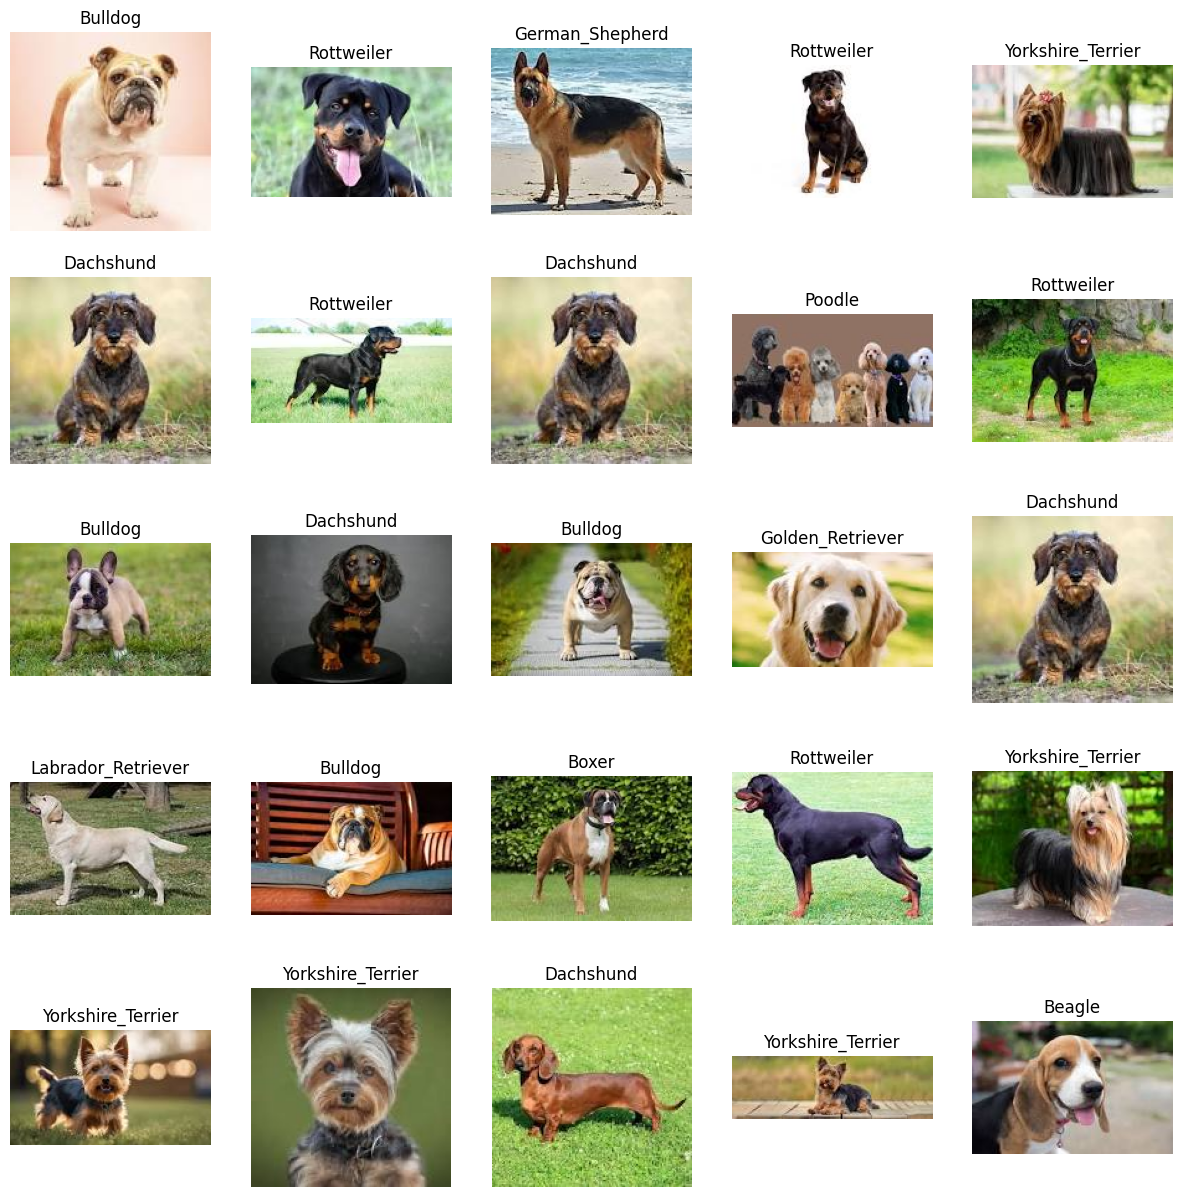

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng()
fig, axes = plt.subplots(fold, 5, figsize=(15, 3 * fold))

for i in range(fold):
  path = f"{data_path}/fold_{i+1}/train/"
  category = os.listdir(path)
  chosen_category = rng.choice(category, size=5)
  for idx, category in enumerate(chosen_category):
    image_path = os.path.join(path, category)
    images = os.listdir(image_path)
    chosen_image = rng.choice(images)
    img = plt.imread(os.path.join(image_path, chosen_image))
    axes[i, idx].imshow(img)
    axes[i, idx].set_title(category)
    axes[i, idx].axis("off")

plt.show();

In [ ]:
img = plt.imread('/kaggle/working/data/fold_1/train/Beagle/Beagle_23.jpg') # random sample
img.min(), img.max(), img.shape

(np.uint8(0), np.uint8(255), (108, 162, 3))

we need to rescale, change dtype, standardize

# Part 3: preprocess images + one hot encode labels

In [ ]:
categories = []
for i in (os.listdir(f"{data_path}/fold_1/train/")):
  categories.append(i)
categories

['Labrador_Retriever',
 'Rottweiler',
 'Beagle',
 'Dachshund',
 'Poodle',
 'Bulldog',
 'German_Shepherd',
 'Boxer',
 'Yorkshire_Terrier',
 'Golden_Retriever']

In [ ]:
import cv2

def preprocess(split, fold_num, resized_shape):

  X = []
  y = []

  path = f"{data_path}/fold_{fold_num}/{split}/"
  for category in os.listdir(path):
    path_category = os.path.join(path, category)
    images = os.listdir(path_category)
    for img_name in images:
      img_path = os.path.join(path_category, img_name)
      image = cv2.imread(img_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image = cv2.resize(image, resized_shape)
      image = image.astype('float32')
      image = image / 255.0
      X.append(image)
      y.append(category)

  X = cp.array(X)
  y = np.array(y) # Changed to np.array to handle string dtypes

  # shuffle
  idx = rng.permutation(len(y))

  X_shuffled = X[idx]
  y_shuffled = y[idx]

  return cp.array(X_shuffled), np.array(y_shuffled)

In [ ]:
def one_hot_encode(labels_array):
  '''
  returns one hot encoded categorical data for an array of labels
  labels_array: array of labels (strings)
  '''
  encoded_list = []
  for label in labels_array: # Iterate through each individual label in the array
    zeroes = cp.zeros(len(categories))
    if label in categories:
      zeroes[categories.index(label)] = 1
    encoded_list.append(zeroes)
  return cp.array(encoded_list)

In [ ]:
shape = (64, 64)

X_train_f1, y_train_f1_raw = preprocess('train', 1, shape)
X_train_f2, y_train_f2_raw = preprocess('train', 2, shape)
X_train_f3, y_train_f3_raw = preprocess('train', 3, shape)
X_train_f4, y_train_f4_raw = preprocess('train', 4, shape)
X_train_f5, y_train_f5_raw = preprocess('train', 5, shape)

X_val_f1, y_val_f1_raw = preprocess('val', 1, shape)
X_val_f2, y_val_f2_raw = preprocess('val', 2, shape)
X_val_f3, y_val_f3_raw = preprocess('val', 3, shape)
X_val_f4, y_val_f4_raw = preprocess('val', 4, shape)
X_val_f5, y_val_f5_raw = preprocess('val', 5, shape)

In [ ]:
print(f'number of examples in fold 1: {len(X_train_f1)}')
print(f'number of examples in fold 2: {len(X_train_f2)}')
print(f'number of examples in fold 3: {len(X_train_f3)}')
print(f'number of examples in fold 4: {len(X_train_f4)}')
print(f'number of examples in fold 5: {len(X_train_f5)}')

number of examples in fold 1: 771
number of examples in fold 2: 774
number of examples in fold 3: 774
number of examples in fold 4: 774
number of examples in fold 5: 775


In [ ]:
y_train_f1_raw

array(['Yorkshire_Terrier', 'Poodle', 'Beagle', 'Labrador_Retriever',
       'Rottweiler', 'Labrador_Retriever', 'Golden_Retriever',
       'German_Shepherd', 'Labrador_Retriever', 'Poodle', 'Poodle',
       'Dachshund', 'Rottweiler', 'Boxer', 'Poodle', 'Boxer',
       'German_Shepherd', 'Golden_Retriever', 'Poodle', 'Bulldog',
       'German_Shepherd', 'Golden_Retriever', 'Rottweiler', 'Boxer',
       'Boxer', 'Boxer', 'Bulldog', 'Labrador_Retriever', 'Poodle',
       'Yorkshire_Terrier', 'Boxer', 'Boxer', 'Beagle', 'Beagle',
       'Golden_Retriever', 'Bulldog', 'Beagle', 'Beagle',
       'German_Shepherd', 'German_Shepherd', 'German_Shepherd',
       'Golden_Retriever', 'Rottweiler', 'Rottweiler', 'Golden_Retriever',
       'German_Shepherd', 'German_Shepherd', 'Boxer', 'Golden_Retriever',
       'Rottweiler', 'Boxer', 'Bulldog', 'Beagle', 'Yorkshire_Terrier',
       'Dachshund', 'Labrador_Retriever', 'Rottweiler',
       'Yorkshire_Terrier', 'Boxer', 'German_Shepherd', 'Rottweiler'

In [ ]:
y_train_f1 = one_hot_encode(y_train_f1_raw)
y_train_f2 = one_hot_encode(y_train_f2_raw)
y_train_f3 = one_hot_encode(y_train_f3_raw)
y_train_f4 = one_hot_encode(y_train_f4_raw)
y_train_f5 = one_hot_encode(y_train_f5_raw)

y_val_f1 = one_hot_encode(y_val_f1_raw)
y_val_f2 = one_hot_encode(y_val_f2_raw)
y_val_f3 = one_hot_encode(y_val_f3_raw)
y_val_f4 = one_hot_encode(y_val_f4_raw)
y_val_f5 = one_hot_encode(y_val_f5_raw)

In [ ]:
y_train_f1

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(771, 10))

# Trying to understanding convolution (as an operation):
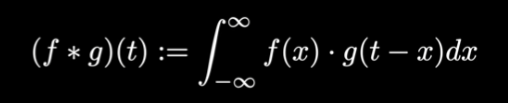

basically, the combination of 2 functions and how they vary through time: [watch](https://www.youtube.com/watch?v=QmcoPYUfbJ8)

In a discrete sense:

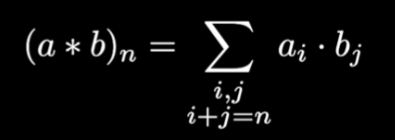

[watch](https://www.youtube.com/watch?v=KuXjwB4LzSA)

# Moving average / Blur:

if our kernel adds up to 1, we are effecitively taking an average of the values and in a computer vision sense, we are "bluring" the image

# Filters:
Hence with varying kernel values we can detect edges, (explained in the 3b1b vid)


# But we will be using FFT Convolution (Fast Fourier transform)

## Fourier transform:
According to the Fourier series, every signal can be represented as a combination of sine and cosine waves

hence,

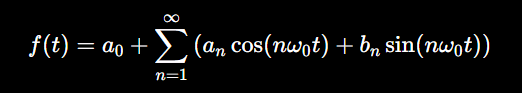

using euler's representation:

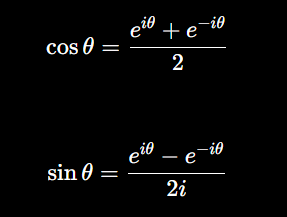

SO basically, our function in time is represented as:

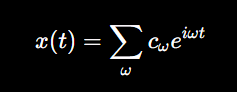

The above equation basically says:

We have a sinusodal function x(t)(f(t) in the earlier example) which is made of multiple other sinusodal function with coefficient ```Cw``` and the euler part.

In the fourier transform, we try and retrive these functions which comprise the master function x(t).

Orthogonality of the integral of complex numbers:

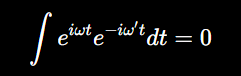

such that both frequencies are not equal and we are integrating for a long time ```t->inf```

imagine:

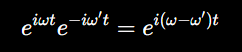

so, using euler expansion:

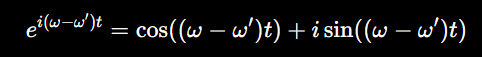

integrating the expression for a long enough time (such that ```t->2npi, n->inf```):

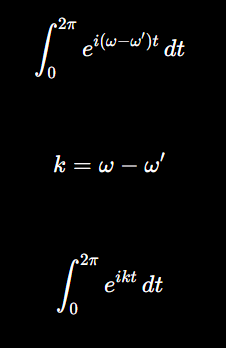

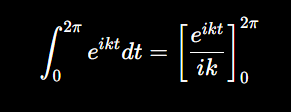

which equals 0 (do the math yourself), hence if the frequencies are unequal, our integral = 0

if frequencies are same

Now, back to our ```x(t)```
multiplying both sides by:

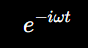

where omega = the "argand plane wrap-around frequency" (watch 3b1b vid on fourier transform)


and integrating (to use our orthogonality property):

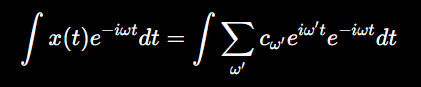

IMP: so because of our orthogonality, all values where frequency of function and wrap-around frequency are inequal, die out and the values remain where the values are equal, hence as we vary our wrap-around frequency, we get the sinusodal functions compromising ```x(t)```

so when freqencies are equal, our integral becomes:

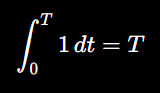

multiplied by the coefficient ```C_w``` which defines our function... hence

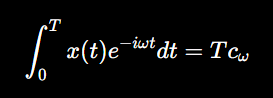

since our coefficients were the only unknowns, we can reconstruct our function as:

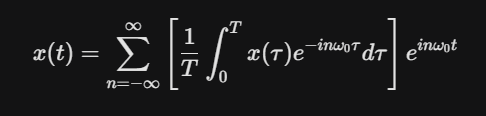

now, these quantities are discrete, we want it turn it applicable for continuous functions so we take the Riemann Sum. as $t$->$inf$
also, $\omega_0$ = 2$\pi$/T (wrap-around frequency), also another thing to notice is that the fourier transform is valid for all integral multiples of the basic wrap-around frequency, meaning our $\omega$ = n$\omega_0$, so in the reimann sum, $\delta$$\omega$ = (n+1)$\omega_0$ - n$\omega_0$ = $\omega_0$ hence taking the reimann sum of the entire thing:

SO, finally our transform is:

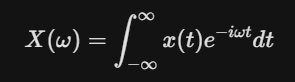





### Naive Discrete-Fourier Transform:

It is nothing but the discrete form of the continuous fourier transform:

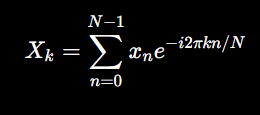

(N-1) because we start from 0

### Fast-Fourier Transform:

In the NDFT, the total complexity is $O(N^2)$ (N inputs, so N multiplications and then N additions)

the FFT algorithm reduces the complexity to $O(NlogN)$

(using the radix-2 derivation where we split the sum into 2 parts not the general cooley-tukey where we split the sum into more than 2 sums)

what we do is break the sum into even and odd index sums: (assume N=even for the radix-2 derivation)

so `n = 2m` for even and `n = (2m+1)`

so for N-1 indexes, N-2 is the largest even digit, hence for even cases
max value of m is `N/2 - 1` and likewise for odd n: max m value is `N/2 - 1`

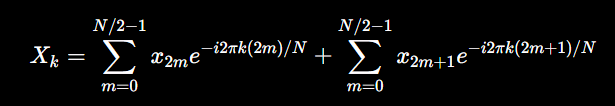

factoring the even and off exponentials:

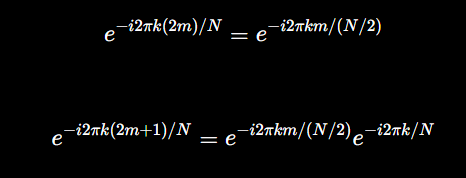

so the transform becomes:

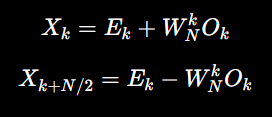

where:

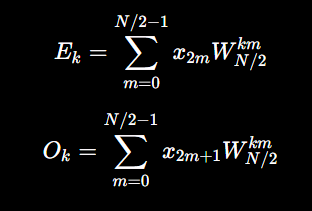

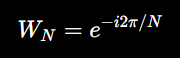

If you split the euler substitution into its real and imaginary parts, you will notice that a symmerty exists, that is for a positive quantity k, N/2 + k results in the cosine and sine of the earlier term prior to N/2+k (N/2), hence we are skipping the (N/2+k)th term so to account for that we use another sum

links:

[Simon Xu: FFT](https://www.youtube.com/watch?v=htCj9exbGo0)

[Simon Xu: DFT](https://www.youtube.com/watch?v=mkGsMWi_j4Q)

[3b1b: fourier transform](https://www.youtube.com/watch?v=spUNpyF58BY&t=1051s) (wrap-around frequency idea taken from here)




### Connection between convolution and fourier thm:

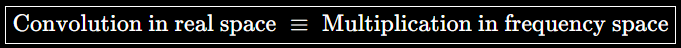

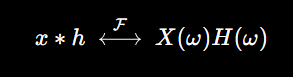

Where F is the fourier transform:

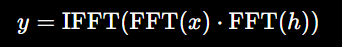

Now this makes things easy and making fft convolution several magnitudes faster than normal convolution, the complexity of normal convolution is $/O(N^2)$ but fft conv is $/O(NlogN)$

Proof of fft conv:

Convolution

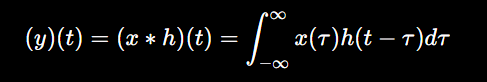

taking the fourier transform of y:

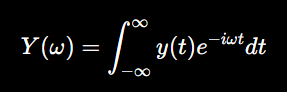

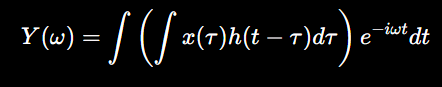

swap the integral based upon the differential term:

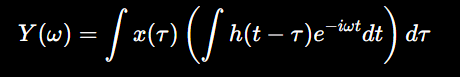

substitute:

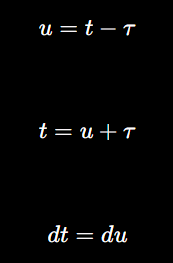

hence we transform the inner integral using the substitution and the result is (after taking the independent term outside of the integral):

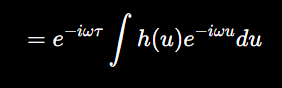

But notice that:

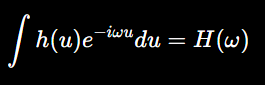

SO,

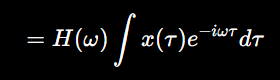

but again,

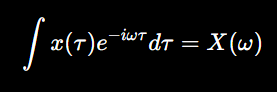

hence overall our equation becomes:

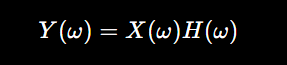

Or in other words:

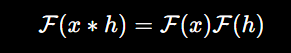

to get the convultion, we just take the inverse fourier of the fourier of the convolution and we get our convolution result way faster

TODO: derive the inverse fourier transform using all our previous knowledge (especially the fourier coefficients equation)

In [ ]:
import cupyx

In [ ]:
l1 = cp.random.randn(10000)
l2 = cp.random.randn(10000)

In [ ]:
%%timeit
np.convolve(l1, l2)

347 µs ± 86.2 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
cupyx.scipy.signal.fftconvolve(l1, l2) # Not nearly as fast as pure scipy but still a tad bit faster

328 µs ± 67 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


hence we can clearly see the difference in the order of magnitudes (had a difference in magnitudes for pure scipy implementation)

implement Sobel
maybe Laplacian
maybe blur/sharpen kernels
visualize outputs
understand why convolution extracts features

### trying our own filters (learning)
1. Sobel (same as taking derivative of our image intensity function $I(x, y)$
a sobel filter detects edges, which is where intensity changes, the kernel of a sobel filter looks like:

$$
S_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$S_x$ is the sobel filter in x direction, it basically is taking the derivative

$$
\frac{\partial I(x, y)}{\partial x}
$$

because as $S_x$ moves left to right in a convolution, we are basically subtracting the right pixel value - the left pixel value

same idea in the y-direction for edge detection in vertical direction

$$
S_y =
\begin{bmatrix}
-1 & -2 & -1 \\
 0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$


so the total edge strength of a particular kernel overlayed on the image is defined as:

$$
|\nabla I| = \sqrt{\left(\frac{\partial I}{\partial x}\right)^2 + \left(\frac{\partial I}{\partial y}\right)^2}
$$

In [ ]:
test_image = X_train_f1[0]
test_image.shape

(64, 64, 3)

In [ ]:
Sx = cp.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

Sy = cp.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

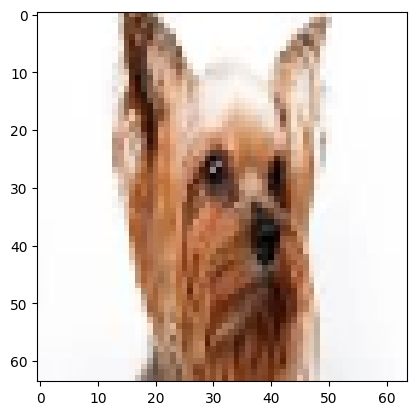

In [ ]:
plt.imshow(test_image.get())

scipy fftconvolve is for 1 and 2 dimenisonal arrays, our image is 3 dimensional (width, height, colour channels) so we can convolve on each channel separately and stack them together afterwards

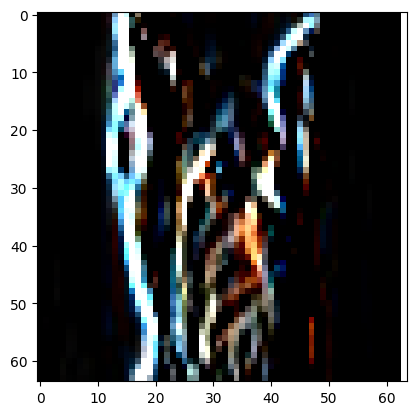

In [ ]:
from cupyx.scipy.signal import fftconvolve as fc

def convolve(image, kernel, clip=True, mode='same'):
  output_image = cp.zeros_like(image)
  for c in range(image.shape[2]):
      output_image[:, :, c] = fc(image[:, :, c], kernel, mode=mode)

  if clip:
    output_image = cp.clip(output_image, 0, 1)
  return output_image

plt.imshow(convolve(test_image, Sx).get());

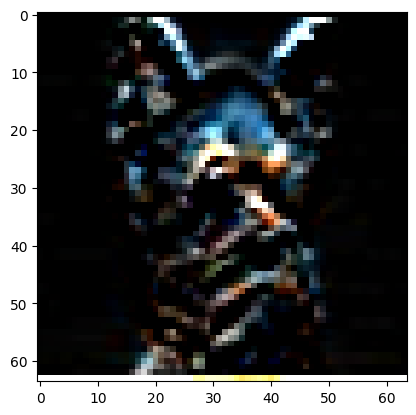

In [ ]:
plt.imshow(convolve(test_image, Sy).get());

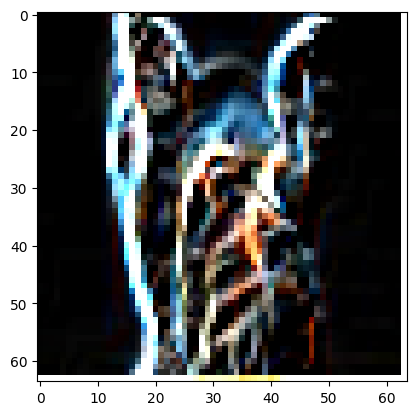

In [ ]:
Ix = convolve(test_image, Sx)
Iy = convolve(test_image, Sy)

edges = cp.sqrt(Ix**2 + Iy**2)
edges = cp.clip(edges, 0, 1)

plt.imshow(edges.get());

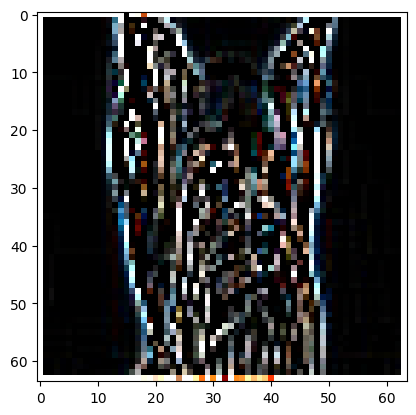

In [ ]:
laplacian_8center = cp.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

plt.imshow(convolve(test_image, laplacian_8center).get());

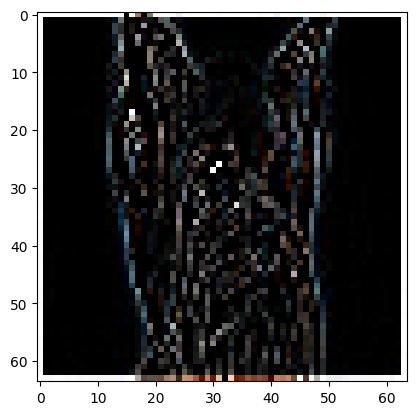

In [ ]:
laplacian_4center = cp.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])

plt.imshow(convolve(test_image, laplacian_4center).get());

The laplacian in vector calculus is defined as:

$$
\nabla^2 f(x, y) = {\frac{\partial^2 f(x, y)}{\partial x^2} + \frac{\partial^2 f(x, y)}{\partial y^2}}
$$

in a matrix / filter sense it is "find how different a spot on the image is compared to its neighbours", these neighbours are dependent on the filter size,
so, in a discrete approximation:

$$
\nabla^2 f(x, y) \approx f_{x+1, y} + f_{x-1, y} + f_{x, y+1} + f_{x, y-1} - 4f_{x,y}
$$

same with eight center


TODO: implement LoG (Laplacian of Gaussian)

# CNNs:

So our kernel strides across the image as we saw and extracts features from it, we add a bias to each pixel of the convolved image generated and we add ReLU to the mix, acting upon each value we get after a convolution of the kernel on the image, if the term is negative after the addition of the bias the term becomes 0 and if the term is positive it remains showing the strength of the feature prsent at that location. so in totality:

- Conv2D creates a feature map
- bias addition tweaks the sensitivity of the features
- relu "switches off" the places where the feature is not that strong / absent
- maxpooling extracts those strong features, and creates a new matrix made of those features, because at the end of the day, we are not interested in "where" the features are but "what" the features are

Example:

this is our image:

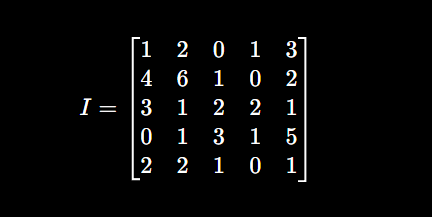

Kernel:

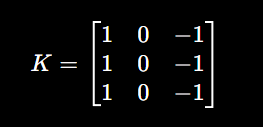

our bias = -2

For our first convolution, at position extreme top left, patch:

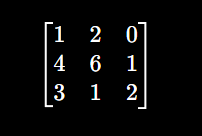

This is our convolution:

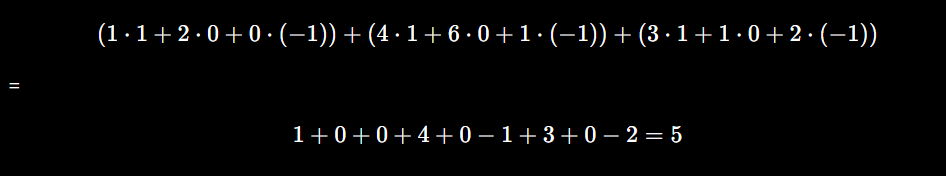

now the result of this region is 5
adding the bias,
5 + (-2) = 3
now using relu, relu(3) = 3
likewise we do the entire thing, and our output becomes:

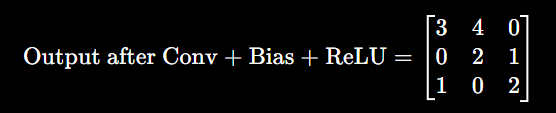



max pool vs avg vs strided conv vs attention

## Building layers and activation functions

In [ ]:
def init_kernels(kernel_shape, initialization="he"):
  '''
  kernel_shape: (number of filters, k, k, channels)
  '''
  filters, kh, kw, c = kernel_shape
  init_shape = kh*kw*c
  convolved_shape = kh*kw*filters
  if initialization == "he":
    std = cp.sqrt(2/init_shape)
  elif initialization == "xavier":
    std = cp.sqrt(2/(init_shape + convolved_shape))
  else:
    raise ValueError("initialization must be 'he' or 'xavier'")
  return cp.random.normal(0, std, size=kernel_shape)


In [ ]:
def init_weights(input_shape, output_shape, initialization="he"):
  '''
  weights shape (output_shape, input_shape)
  '''
  if initialization == "he":
    std = cp.sqrt(2/input_shape)
  elif initialization == "xavier":
    std = cp.sqrt(2/(output_shape + input_shape))
  else:
    raise ValueError("initialization must be 'he' or 'xavier'")
  return cp.random.normal(0, std, size=(input_shape, output_shape))


#### Doubt:

Instead of manually deriving the calculus and backward passes for each layer like Conv2D, can we implement a framework that stores the pre-operation states and operation history to dynamically calculate the exact inverse operations during backpropagation? Maybe autograd does that, I am not sure how autograd works though

#### Note:
in backpropagaton, we want to calculate the derivatives with respect to all the learnable/optimizeable values and we also get the derivative wrt to the input, lets understand why:

we optimize the loss function wrt to the learnable parameters, in doing so, using chainrule we get a derivative of loss function with respect to the input, now this derivative is also the loss function with respect to the output of the next layer, which is our input in our ```.backprop()``` method.

### Backpropagation in CNNs:
we basically want to optimize our N trainable params wrt to the loss by minimizing it

So, if our loss function = L, one of the trainable params = w1 (kernel in our Conv2D_layer):

$$
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial layer_{n}} . \frac{\partial layer_{n}}{\partial layer_{n-1}} . \frac{\partial layer_{n-1}}{\partial layer_{n-2}} ...\frac{\partial layer_1}{\partial w_1}
$$

and suppose another one of our trainable param exists in our n-1 layer:
$$
\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial layer_{n}} . \frac{\partial layer_{n}}{\partial layer_{n-1}} . \frac{\partial layer_{n-1}}{\partial w_2}
$$

in such a way, we optimize our params, so in a cnn case, these layers may be conv2d, maxpool, relu, flatten so we calculate the derivatives using a pen and paper and use the derivatives in the code, for the fully-connected part of the CNN, we already know the derivatives, as we saw in the [logistic regression](https://github.com/flackojodie/LogisticRegression-puremath) puremath book

### Backpropagation in flatten:
- there are no learnable params in a flatten operation, afterall its just a tensor reshape, so how do we calculate the derivatives in this case?

we dont, the general idea of backpropagation is "traversing" backward thru the net and finding the relation of the loss function with our trainable parameters, so in case of general math operations, we just reverse the operation, so the backprop for flatten is just to "unflatten" the flattened feature map.

### Backpropagation in maxpool:
Using the same logic in flatten backprop, we basically "go back" to the feature map prior to the maxpool operation, but how tho, afterall in maxpool we only take the maximum pixel values that are within the frame of our window that strides across the image, only those values are selected and propagated forward through the network and ultimately only these values affect the loss function and we lose the other pixel values, so to combat this, we store the coordinate of where we got that max value and make another fresh new map, where we set the pixel value on which we find a max value in the original image equal to that value and set the other values to 0.

### Backpropagation in relu:

my direct differentiation of relu wrt the input, its just 1 if input>0 and 0 is input<0


### Backpropagation in convolution layer:
let our image input be a 3x3 image:

$$
\begin{matrix}
    I_{11} & I_{12} & I_{13}\\
    I_{21} & I_{22} & I_{23}\\
    I_{31} & I_{32} & I_{33}\\
\end{matrix}
$$

our kernel (W1) be a 2x2 matrix:

\begin{matrix}
    W_{11} & W_{12} \\
    W_{21} & W_{22}
\end{matrix}

and our Z1 be the result of conv(I, W1)

\begin{matrix}
    z_{11} & z_{12} \\
    z_{21} & z_{22}
\end{matrix}

and our bias = $b_1$

$$
z_{11} = I_{11}W_{11} + I_{12}W_{12} + I_{21}W_{21} + I_{22}W_{22} + b1 \\
z_{12} = I_{12}W_{11} + I_{13}W_{12} + I_{22}W_{21} + I_{23}W_{22} + b1 \\
z_{21} = I_{21}W_{11} + I_{22}W_{12} + I_{31}W_{21} + I_{32}W_{22} + b1 \\
z_{22} = I_{22}W_{11} + I_{23}W_{12} + I_{32}W_{21} + I_{33}W_{22} + b1
$$

#### 1. For bias:

$$
\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_{1}} . \frac{\partial z_{1}}{\partial b_{1}} = \frac{\partial L}{\partial z_{11}} . \frac{\partial z_{11}}{\partial b_{1}} + \frac{\partial L}{\partial z_{12}} . \frac{\partial z_{12}}{\partial b_{1}} + \frac{\partial L}{\partial z_{21}} . \frac{\partial z_{21}}{\partial b_{1}} + \frac{\partial L}{\partial z_{22}} . \frac{\partial z_{22}}{\partial b_{1}}
$$

but the derivative of $Z_{ij}$ wrt $b_1$ is 1, so the ans is $∑_{i,j=1} \frac{\partial L}{\partial z_{ij}}$

#### 2. For weights:

$$
\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial z_{11}} . \frac{\partial z_{11}}{\partial w_{11}} + \frac{\partial L}{\partial z_{12}} . \frac{\partial z_{12}}{\partial w_{11}} + \frac{\partial L}{\partial z_{21}} . \frac{\partial z_{21}}{\partial w_{11}} + \frac{\partial L}{\partial z_{22}} . \frac{\partial z_{22}}{\partial w_{11}} \\
\frac{\partial L}{\partial w_{12}} = \frac{\partial L}{\partial z_{11}} . \frac{\partial z_{11}}{\partial w_{12}} + \frac{\partial L}{\partial z_{12}} . \frac{\partial z_{12}}{\partial w_{12}} + \frac{\partial L}{\partial z_{21}} . \frac{\partial z_{21}}{\partial w_{12}} + \frac{\partial L}{\partial z_{22}} . \frac{\partial z_{22}}{\partial w_{12}} \\
...\\
...
$$

so on, we can calculate $\frac{\partial z_{ij}}{\partial w_{ij}}$ using the earlier defined relation, its just $I_{ij}$

we can simplify the entire thing and write it as:

$$
\frac{\partial L}{\partial w_{ij}} = conv(X, \frac{\partial L}{\partial z_{ij}})
$$

$\frac{\partial L}{\partial z_{ij}}$ is the loss that has propagated back the net upto the conv layer and X is the input image

In [ ]:
class conv2d: # Takes care of our strided conv
  def __init__(self, kernel_shape, stride=1, init="he", name='conv2d'):
    self.stride = stride
    self.kernels = init_kernels(
        kernel_shape,
        initialization=init
    )
    self.kernel_shape = kernel_shape
    self.biases = cp.zeros(self.kernel_shape[0])
    self._name = name
  def forward(self, input):
    """
    Performs fftconv
    input: [height, width, 3]
    kernels: [number of filters, k, k, 3]
    biases: [number of filters,]
    stride: number of pixels to travel at a time
    """
    if input.ndim == 3:   # added for batch
        input = cp.expand_dims(input, axis=0)
    self.input = input
    self.filters = self.kernels.shape[0]
    self.kh = self.kernels.shape[1]
    self.kw = self.kernels.shape[2]
    self.kc = self.kernels.shape[3]
    batch = input.shape[0]
    output_image = cp.zeros((
        batch,
        (input.shape[1]-1) // self.stride + 1,
        (input.shape[2]-1) // self.stride + 1,
        self.filters
    ))

    for f in range(self.filters):
      for b in range(batch):   # added
        features = cp.zeros_like(input[b, :, :, 0])
        for i in range(input.shape[3]):
          features = features + fc(
              input[b, :, :, i],
              self.kernels[f, :, :, i],
              mode="same"
          )
        features = features[::self.stride, ::self.stride]
        features = features + self.biases[f]
        output_image[b, :, :, f] = features
    return output_image

  def backprop(self, grads):
    if grads.ndim == 3:
        grads = cp.expand_dims(grads, axis=0)
    H, W, C_input = self.input.shape[1], self.input.shape[2], self.input.shape[3]
    C_filters = self.filters
    self.dk = cp.zeros_like(self.kernels)
    self.db = cp.zeros_like(self.biases)
    self.dinput = cp.zeros_like(self.input)

    dilated_grads = cp.zeros((self.input.shape[0], H, W, C_filters))
    dilated_grads[:, ::self.stride, ::self.stride, :] = grads

    for b in range(self.input.shape[0]):
      for f in range(C_filters):
        self.db[f] = cp.sum(grads[b, :, :, f])
        for c in range(C_input):
          unpadded_dk = fc(
              self.input[b, :, :, c],
              cp.flip(dilated_grads[b, :, :, f], axis=(0, 1)),
              mode="valid"
          )
          rh, rw = unpadded_dk.shape
          pad_h = max(0, (self.kh - rh) // 2)
          pad_w = max(0, (self.kw - rw) // 2)
          padded_dk = cp.pad(unpadded_dk, (
                        (pad_h, self.kh - rh - pad_h),
                        (pad_w, self.kw - rw - pad_w)),
                        mode='constant')
          self.dk[f, :, :, c] += padded_dk
          self.dinput[b, :, :, c] = self.dinput[b, :, :, c] + fc(
              dilated_grads[b, :, :, f],
              cp.flip(self.kernels[f, :, :, c], axis = (0, 1)),
              mode="same"
          )
    self.dk /= self.input.shape[0]
    self.db /= self.input.shape[0]
    return self.dinput
  def name(self):
    return self._name

In [ ]:
class dense:
  def __init__(self, input_size, output_size, init="he", name='dense'):
    self.weights = init_weights(input_size, output_size, init)
    self.biases = cp.zeros(output_size)
    self._name = name
  def forward(self, input):
    if input.ndim == 1:
        input = cp.expand_dims(input, axis=0)
    self.input = input # self.input will be (input_size,) for a single sample
    return input @ self.weights + self.biases
  def backprop(self, grads): # grads will be (output_size,) for a single sample
    self.dw = cp.outer(self.input, grads) if grads.ndim == 1 else cp.dot(self.input.T, grads)
    self.db = cp.sum(grads, axis=0)
    return grads @ self.weights.T
  def name(self):
    return self._name

In [ ]:
class pool2d: # We could have make this into a function as well because we dont need to init anything learnable, the only reason we are doing this is so that making models are easier
  def __init__(self, filter_size=2, strides=2, mode="max", name='pool2d'):
    self.filter_size = filter_size
    self.strides = strides
    self.mode = mode
    self._name = name
  def forward(self, x):
    '''
    input: input image (W, H, colour channels)
    filter size: square matrix of order filter size
    strides: how many pixels it moves
    mode: "max" for maxpooling or "average" for average pooling
    '''
    if x.ndim == 3:   # added for batch support
        x = cp.expand_dims(x, axis=0)

    self.input = x
    H, W, C = x.shape[1], x.shape[2], x.shape[3]   # modified
    out_h = (H - self.filter_size) // self.strides + 1
    out_w = (W - self.filter_size) // self.strides + 1
    output = cp.zeros((x.shape[0], out_h, out_w, C))   # modified

    for c in range(C):
        for i in range(out_h):
            for j in range(out_w):
                if self.mode == "max":
                    output[:, i, j, c] = cp.max(x[
                      :,
                      i * self.strides:i * self.strides + self.filter_size,
                      j * self.strides:j * self.strides + self.filter_size,
                      c
                    ], axis=(1,2))
                elif self.mode == "average":
                    output[:, i, j, c] = cp.mean(x[
                      :,
                      i * self.strides:i * self.strides + self.filter_size,
                      j * self.strides:j * self.strides + self.filter_size,
                      c
                    ], axis=(1,2))
                else:
                    raise ValueError("mode must be 'max' or 'average'")
    return output

  def backprop(self, grads):
    if grads.ndim == 3:
        grads = cp.expand_dims(grads, axis=0)
    H_input, W_input, C_input = self.input.shape[1], self.input.shape[2], self.input.shape[3]
    self.dinput = cp.zeros_like(self.input)
    H_grads, W_grads, C_grads = grads.shape[1], grads.shape[2], grads.shape[3]

    for c in range(C_grads):
      for i in range(H_grads):
        for j in range(W_grads):
          h_start = i * self.strides
          h_end = h_start + self.filter_size
          w_start = j * self.strides
          w_end = w_start + self.filter_size
          grad_output_cell = grads[:, i, j, c]

          if self.mode == "max":
            input_patch = self.input[:, h_start:h_end, w_start:w_end, c]
            mask = (input_patch == cp.max(input_patch, axis=(1,2), keepdims=True))
            self.dinput[:, h_start:h_end, w_start:w_end, c] += mask * grad_output_cell[:, None, None]
          elif self.mode == "average":
            self.dinput[:, h_start:h_end, w_start:w_end, c] += grad_output_cell[:, None, None] / (self.filter_size ** 2)

    return self.dinput

  def name(self):
    return self._name

### Attention:

This learns the importance of the features dynamically

- spatial attention: "where" should I look
- channel attention: "what" matters

So we will try and implement channel attention

Channel attention/Squeeze-and-Excitation network asks a important question - "which colour channels matter more"

What do we actually do then?
steps:
- We first get the total global pooled features of the image
(SE nets assume the overall activation strength of a channel is directly proportional to its importance as a feature, which is a doubt I had cause If we collapse each channel into one scalar using global average pooling, aren't we reducing spatial information and the channel to a single statistic?)

  TODO: implement some other pooling function other than global avg

- Then we building a small logistic neural network that would find a value of $\alpha_c$ which is the weight we multiply to the channels of the initial image volume (im using the word volume here because the image has 3 dimensions)

  our mini nn should look like this:

  $$
  \alpha = \sigma(W_2ReLU(W_1Z)) \\
  Z = pooling2d(convoluted-image) \\
  \sigma = sigmoid
  $$

  we use sigmoid because we want our alpha to get scaled [0, 1] (we could use some other function too such as $$sin^2x$$ but the derivatives get messy and sigmoid derivates are easier to calculate and use)

- finally we multiply the weights to the image and that is our final output, so we supress our "less valueable" channels and amplify our "important" channels



In [ ]:
class relu:
  def __init__(self, name='relu'):
    self._name = name
  def forward(self, input):
    '''
    returns 0 if input is negative, else input
    '''
    if input.ndim == 1:   # added for safety
        input = cp.expand_dims(input, axis=0)
    self.input = input
    return cp.maximum(0, input)
  def backprop(self, grads):
    return grads * (self.input>0) # derivative of relu is (np.input > 0)(performs element-wise comparison) and we multiply it by grads to get the total grads upto that point.
  def name(self):
    return self._name

class sigmoid:
  def __init__(self, name='sigmoid'):
    self._name = name
  def forward(self, input):
    '''
    returns the output for a definite input on the logistic curve
    '''
    if input.ndim == 1:
        input = cp.expand_dims(input, axis=0)
    self.input = input
    return 1 / (1 + cp.exp(-input))
  def backprop(self, grad):
    x = self.forward(self.input)
    return grad * x * (1 - x)
  def name(self):
    return self._name

class globalaveragepool:
  def __init__(self, name='globalaveragepool'):
    self._name = name
  def forward(self, input):
    '''
    Returns the mean values of the individual feature maps
    return shape; (pool value of first FM, pool value of second FM, pool value of third FM)
    '''
    if input.ndim == 3:   # added for batch
        input = cp.expand_dims(input, axis=0)
    self.input = input
    return cp.mean(input, axis=(1, 2))   # changed from (0,1) to (1,2) for batch
  def backprop(self, grads):
    if grads.ndim == 1:   # added for batch
        grads = cp.expand_dims(grads, axis=0)
    H, W, C = self.input.shape[1], self.input.shape[2], self.input.shape[3]
    spatial_area = H * W
    scaled_grads = grads / spatial_area
    return cp.broadcast_to(scaled_grads[:, None, None, :], self.input.shape)
  def name(self):
    return self._name

In [ ]:
class LightChannelAttention:
    def __init__(self, input_shape, output_shape, init='he', name='LightChannelAttention'):
        self.w1 = init_weights(input_shape, output_shape, init)
        self.w2 = init_weights(output_shape, input_shape, init)
        self.sigmoid = sigmoid()
        self.gap = globalaveragepool()
        self.relu = relu()
        self._name = name
    def forward(self, input):
        if input.ndim == 3:
            input = cp.expand_dims(input, axis=0)

        self.input = input
        self.gap_out = self.gap.forward(input)
        self.x1 = self.gap_out @ self.w1
        self.x2 = self.relu.forward(self.x1)
        self.alpha = self.sigmoid.forward(self.x2 @ self.w2)
        self.alpha_3d = cp.expand_dims(cp.expand_dims(self.alpha, axis=1), axis=1)
        return self.alpha_3d * input
    def backprop(self, grads):
        if grads.ndim == 3:
            grads = cp.expand_dims(grads, axis=0)

        self.dinput_direct = grads * self.alpha_3d
        self.dalpha = cp.sum(grads * self.input, axis=(1, 2))
        dsigmoid = self.sigmoid.backprop(self.dalpha)

        # calculation for dW2: (output_shape, batch_size) @ (batch_size, input_shape) -> (output_shape, input_shape)
        self.dw2 = self.x2.T @ dsigmoid
        self.dw2 /= self.input.shape[0]
        self.dx2 = dsigmoid @ self.w2.T
        drelu = self.relu.backprop(self.dx2)

        # calculation for dW1: (input_shape, batch_size) @ (batch_size, output_shape) -> (input_shape, output_shape)
        self.dw1 = self.gap_out.T @ drelu
        self.dw1 /= self.input.shape[0]

        dgap = drelu @ self.w1.T
        self.dinput_from_attention = self.gap.backprop(dgap)
        self.dinput_total = self.dinput_direct + self.dinput_from_attention
        return self.dinput_total
    def name(self):
        return self._name

### Backpropagation in Light Attention:

our attention model can be expressed using these variables:

- GAP layer:

$$g = \frac{1}{H \times W} \sum_{h=1}^{H} \sum_{w=1}^{W} X_{h,w,:}$$

dot with weight 1 and relu to the entire thing:

$$x_1 = g \cdot W_1$$$$x_2 = \max(0, x_1)$$

- dot with weight 2 and sigmoid:

$$\alpha = \sigma(x_2 \cdot W_2)$$

- multiply input by alpha

$$Y_{h,w,c} = \alpha_c \cdot X_{h,w,c}$$

since we are using input twice, we need to make 2 differentials and add them together to find the total derivative

First part (direct derivative of X, last part of our attention):

$$\frac{\partial \mathcal{L}}{\partial X_{\text{direct}}} = \frac{\partial \mathcal{L}}{\partial Y} \cdot \alpha$$

Second part (differentiaing the attention layers):

- derivative wrt alpha: (try yourself, take a random featuremap and alpha and differentiate)
$$\frac{\partial \mathcal{L}}{\partial \alpha_c} = \sum_{h=1}^{H} \sum_{w=1}^{W} \left( \frac{\partial \mathcal{L}}{\partial Y_{hwc}} \cdot \frac{\partial Y_{hwc}}{\partial \alpha_c} \right) \\
\frac{\partial \mathcal{L}}{\partial \alpha_c} = \sum_{h=1}^{H} \sum_{w=1}^{W} \left( \frac{\partial \mathcal{L}}{\partial Y_{h,w,c}} \cdot X_{h,w,c} \right)$$

- derivative of sigmoid:
$$
\frac{\partial \mathcal{L}}{\partial \text{sigmoid}} = \frac{\partial \mathcal{L}}{\partial \alpha} \odot \alpha \odot (1 - \alpha)\\
$$
$\odot$ signifies element-wise multiplication

- derivative wrt W2 and X2:

$$\frac{\partial \mathcal{L}}{\partial W_2} = x_2^T \cdot \frac{\partial \mathcal{L}}{\partial \text{sigmoid}}$$$$\frac{\partial \mathcal{L}}{\partial x_2} = \frac{\partial \mathcal{L}}{\partial \text{sigmoid}} \cdot W_2^T$$

- derivative wrt relu:

$$\frac{\partial \mathcal{L}}{\partial x_1} = \frac{\partial \mathcal{L}}{\partial x_2} \odot (x_1 > 0)$$

- derivative wrt GAP:

$$\frac{\partial \mathcal{L}}{\partial X_{\text{attention}}} = \frac{1}{H \times W} \cdot \frac{\partial \mathcal{L}}{\partial g}$$

Hence, total derivative is,

$$\frac{\partial \mathcal{L}}{\partial X_{\text{total}}} = \frac{\partial \mathcal{L}}{\partial X_{\text{direct}}} + \frac{\partial \mathcal{L}}{\partial X_{\text{attention}}}$$



In [ ]:
class flatten:
  def __init__(self, name='flatten'):
    self._name = name
  def forward(self, input):
    self.input = input
    if input.ndim == 4:
        return input.reshape(input.shape[0], -1)
    return self.input.flatten()
  def backprop(self, grads):
    return grads.reshape(self.input.shape)
  def name(self):
    return self._name

### Softmax, Temperature and Boltzmann:
It is used to transform our logits (raw values output by the model) into probabilities. $e^x$ is always positive, so its outputs are always +ve, which we want as all our probabilities should be +ve as well and we divide it by the sum of of the $e^x$ for all categories so that our values are normalized and lie between (0, 1)

But, why dont we use something other, suppose a shifted parabola with a -ve discriminant and coefficient of x^2 being +ve so that it has no roots, or something like acos(), we do this because of the properties of softmax

Softmax:

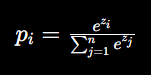

we can also use the numerically better version:

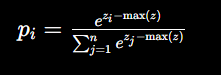

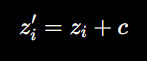

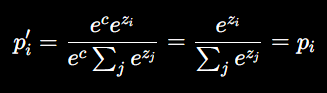

This is important because is our logits are large (1002) for example, we can just shift them by the equally large value and shift it into something like $e^2$ from $e^{1002}$

Temperature:
temperature in a softmax controls how "far" the probabilities are from each other in a sense,
take for example: our model predicts malinois as a breed with a probability of 0.7 and a german shephard with a probability of 0.2, if our temperatue is set to T, now suppose we tweak the temperature a bit, we see that our probability value changes, its not that our model "loses confidence" that the breed is a malinois, its just that the scale of entire probability structure shifts into another scale where suppose our malinois probability is 0.99 and our german shephard is 0.001, now our softmax kinda behaves like an $argmax$.

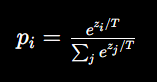

Z are logits and T is our temperature, $ T \in (0, \infty) $
for a low temperature (T<1), our values scale large and our probabilities separate violently, and for T $\to 0$ we get a "hardmax" or an argmax
as our temperature $\to \infty$, we get a uniform distribution

Boltzmann/Gibbs distribution:
softmax was taken from the idea of boltzmann in statistical mechanics:

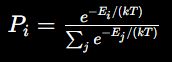

k is nothing but the boltzmann constant, used to account for the units, so we dont need that

in physics, stability and energy are inversely related hence for a system to attain high stability, its energy


(maybe id let temperate be a learnable parameter for fun, lets see)

### Simplification of softmax and crossentropy:

$$
\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z_i} .\frac{\partial z_i}{\partial w}
$$

also let:

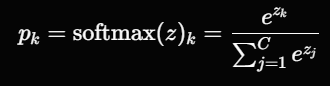

$
Z_i = ∑w_i.x + b
$

hence the derivative of $Z_i$ wrt w is just x.

The difficult part is the initial part:

$$
\frac{\partial L}{\partial z_i} = \frac{\partial L}{\partial p_k}.\frac{\partial p_k}{\partial z_i}
$$

and this makes sense because our loss function (L) is a function of p_k, which is the predicted probability for the k-th class

$$
L = -\sum_{k=1}^{k=C} y_k.log(p_k)
$$

C = number of classes,
y = is the one hot encoded true labels.

refer to artem kirsanov for getting a mathematical intuition on crossentropy

hence, working on our previous chain rule:

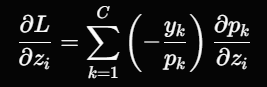

(differentiation of the first term in the chain rule)

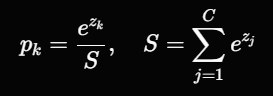

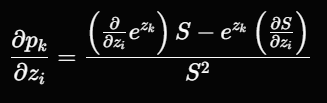

using quotient rule.

defining Kronecker-delta function:

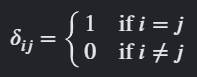

Now, solving our earlier derivative:

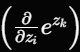

What does the above expression really say?, $e^z_k$ is just the power of euler's number to the kth logit, and we differentiate this expression to the specific expression $z_i$, meaning WHEN $z_k = z_i$ our derivative is not 0, but $e^z_i$, but if $z_k \ne z_i$ then our derivative is 0 because, we are effectively just differentiating a constant. hence it makes sense to split our sum which can be done using our earlier defined kronecker-delta function.

as for S, S is just a sum of all $e^k$ values, obviously, at some instant when k=i, our derivative makes sense and is equal to $e^z_i$ and all the other values are just 0 (differentiating wrt a constant)

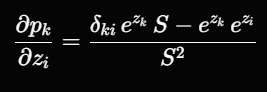

So, if k=i, kd function = 1, if k $\ne$ i, kd function = 0, and our differential makes sense that way.

using our prior defination of $p_k$, we can now write the terms are $p_k$

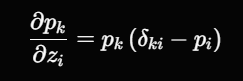

Substituting this into our chain rule:

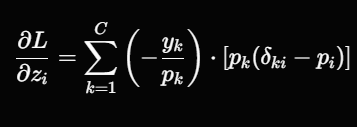

Breaking the sum, wrt the kroncker-delta function:

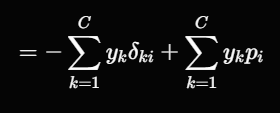

note that keeping the kd function definition in mind, if k does not equal i, our kd function is just 0, so our sum does not exist, and when k=i, our sum is just simplifies into $y_i$ (read this line keeping the expression in mind)

as for the next sum, $p_i$ is independent of k so we can remove it our of the sum, hence our second sum if just the sum of our one hot encoded y multiplied by our probability distribution (p),now obviously the sum of the one-hot encoded values is for each class, so the second sum is just our probability distribution

so effectively our loss wrt z_i chain rule is just:

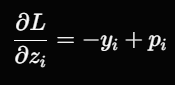

Substituting back into our original chain rule,

$$
\frac{\partial L}{\partial w} = (p_i - y_i).x
$$

and for our bias chain rule:

$$
\frac{\partial L}{\partial b} = (p_i - y_i)
$$



### Backpropagation in softmax (nonlearnable)
as we saw earlier:

$$\frac{\partial p_i}{\partial x_j} = p_i \delta_{ij} - p_i p_j$$

using the backprop chain rule:

$$dx_j = \sum_{i} g_i (p_i \delta_{ij} - p_i p_j)$$

$$dx_j = \sum_{i} (g_i p_i \delta_{ij}) - \sum_{i} (g_i p_i p_j)$$

so, as seen earlier the first term simplifies to be $g_j p_j$

$$dx_j = p_j \left( g_j - \sum_{i} g_i p_i \right)$$

In [ ]:
class nonlearnable_softmax:
  def __init__(self, name='nonlearnable_softmax'):
    self._name = name
  def forward(self, logits, temperature=1.0):
    # logits expected to be (num_classes,) for single sample
    if logits.ndim == 1:   # added for batch
        logits = cp.expand_dims(logits, axis=0)
    max_logits = cp.max(logits, axis=1, keepdims=True)
    scaled_logits = logits - max_logits
    self.out = cp.exp(scaled_logits / temperature) / cp.sum(cp.exp(scaled_logits / temperature), axis=1, keepdims=True)
    return self.out
  def backprop(self, grads):
    # grads expected to be (num_classes,) for single sample
    sum_gradpreds = cp.sum(grads * self.out, axis=1, keepdims=True)
    self.dinput = self.out * (grads - sum_gradpreds)
    return self.dinput
  def name(self):
    return self._name

### Making our loss function

in BCE we use this:

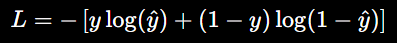

it basically is the sum of the crossentropy of  both classes in a binary problem

so if we extend this defination to our own case, our loss function becomes:

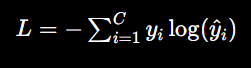

where $y_i$ is obviously our one-hot encoded labels

### But why cant we optimize like we do in classical calulus?
in general calculus, we set the derivatives of the function we want to optimize to 0, in a general 2d sense, this works, geometrically we basically find the "x" values of the point on the curve where the curve has a bend, "derivatives = 0, so slope at that point = 0" but now the problem is this "slope=0" logic works for maxima and minima both, so we differentiate the function again and if the second derivative is +ve, we say that its a minima, is -ve a maxima, like we do in basica HS math, so why cant we do that in this problem, jsut get the derivatives of the loss wrt to the params = 0, use chainrule and differentiate and find the "best" weights and biases

The problem is with the dimentionality we are not dealing in 2d anymore, our problem has scaled upto thousands of dimensions. the idea might still work but the complexity of the problem scales infinitely, the algebra is just too complex because of the high degree of non-linearity, hence the best way to go about this is treat our probability distribution as a terrain and try and find the lowest point and find the params at that point, which is gradient descent

In [ ]:
class crossentropy:
  def __init__(self, name='crossentropy'):
    self._name = name
  def forward(self, y_hat, y_labels, eps=1e-8):
    '''
    y_hat: predictions
    labels: one hot encoded labels
    eps: epsilon, very small value keeps the math from breaking
    returns the multiclass categorical crossentropy of our predictions and labels
    '''
    self.y_hat = y_hat
    self.y_labels = y_labels
    self.eps = eps
    clipped_preds = cp.clip(y_hat, eps, 1-eps)
    return -cp.mean(cp.sum(y_labels * cp.log(clipped_preds + eps), axis=1))
  def backprop(self): # derivative of crossentropy wrt softmax (explained in part 2: logistic regression)
    return self.y_hat - self.y_labels
  def name(self):
    return self._name

### Making the model

In [ ]:
class sequential:
    def __init__(self, layers):
        self.layers = layers
    def forward(self, x, training=True):
        for layer in self.layers:

            try:
                x = layer.forward(x, training=training)

            except TypeError:
                x = layer.forward(x)

        return x
    def backprop(self, dloss):
        for layer in reversed(self.layers):
            dloss = layer.backprop(dloss)
        return dloss
    def summary(self, input_shape=(64, 64, 3)):
        x = cp.ones(input_shape)
        print(f"{'Layer':20} {'Output Shape'}")
        print("-"*40)
        for layer in self.layers:
          x = layer.forward(x)
          print(f"{str(layer.name()):20} {x.shape}")
        print("-"*40)
        print(f'Final Shape: {x.shape}')

In [ ]:
model_1 = sequential([
    conv2d(kernel_shape=(16, 3, 3, 3), stride=1, name='Conv2D_1'),
    relu(name='ReLU_1'),
    pool2d(filter_size=2, name='MaxPool2D_1'),
    conv2d(kernel_shape=(32, 3, 3, 16), stride=1, name='Conv2D_2'),
    relu(name='ReLU_2'),
    pool2d(filter_size=2, name='MaxPool2D_2'),
    globalaveragepool(name='GlobalAveragePooling_2D'),
    dense(input_size=32, output_size=128, name='Dense_1'),
    relu(name='ReLU_3'),
    dense(input_size=128, output_size=10, name='Dense_2'),
    nonlearnable_softmax(name='NonLearnable_Softmax')
])

In [ ]:
model_1.summary()

Layer                Output Shape
----------------------------------------
Conv2D_1             (1, 64, 64, 16)
ReLU_1               (1, 64, 64, 16)
MaxPool2D_1          (1, 32, 32, 16)
Conv2D_2             (1, 32, 32, 32)
ReLU_2               (1, 32, 32, 32)
MaxPool2D_2          (1, 16, 16, 32)
GlobalAveragePooling_2D (1, 32)
Dense_1              (1, 128)
ReLU_3               (1, 128)
Dense_2              (1, 10)
NonLearnable_Softmax (1, 10)
----------------------------------------
Final Shape: (1, 10)


is it possible that i train this model archiecture for like 100 epochs get my weights and biases half-trained, then feed those half-trained wnb into another model containing my attention layer for like 50 to 25 epochs and then shift to another netork for the ANN part of the CNN (dense layers) with learnable temperature for my softmax for like 20-10 epochs and get those final w n b?

In [ ]:
model_1.backprop(model_1.forward(cp.random.randn(64, 64, 3)))

array([[[[-6.13699808e-05, -4.80441141e-05,  6.06117013e-05],
         [-1.79669412e-04,  3.61207840e-05, -5.69962174e-05],
         [ 1.75046523e-04, -1.31756942e-04, -1.09492452e-05],
         ...,
         [ 1.96118912e-05, -8.18751454e-05, -7.89485380e-05],
         [ 7.04220599e-06, -3.86005350e-05, -8.04706559e-05],
         [ 7.92466638e-05, -1.73023191e-05,  1.21221253e-05]],

        [[ 4.34396534e-05, -1.83434351e-04,  1.32000647e-04],
         [-8.53588598e-06,  1.33704310e-05, -1.85436047e-04],
         [ 1.93504946e-04,  1.34314939e-05,  8.30810518e-05],
         ...,
         [ 3.89341925e-05,  3.99205838e-05, -7.47469171e-05],
         [ 1.24322492e-04, -2.16695825e-04,  9.36112173e-05],
         [ 3.05084574e-05, -1.22632512e-04,  2.59712943e-05]],

        [[-4.62532155e-05,  8.10846281e-05, -1.07519998e-04],
         [ 9.23589903e-05,  2.41791834e-05, -2.78920013e-05],
         [-1.80084896e-04,  1.07557626e-04,  2.26640118e-04],
         ...,
         [ 2.02191486e-0

In [ ]:
!pip install cupy-cuda12x -q

In [ ]:
import copy
import cv2
import numpy as np
import cupy as cp

def TrainNoOptim(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    lr=1e-4,
    batch_size=16
):
    """
    K-fold cross-validation where:
    - Each fold is held out as validation
    - Model trains on the OTHER 4 folds
    - Model is RESET for each fold

    X_fold: list of 5 arrays, each containing ALL samples for that fold
    y_fold: list of 5 arrays, each containing ALL labels for that fold
    """
    K = 5
    criterion = crossentropy()
    fold_results = []

    # Convert all folds to GPU once (for efficiency)
    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]
    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        # ============================================================
        # CREATE TRAINING SET: concatenate all folds EXCEPT val_fold
        # ============================================================
        train_indices = [i for i in range(K) if i != val_fold]

        X_train_gpu = cp.concatenate([X_fold_gpu[i] for i in train_indices], axis=0)
        y_train_gpu = cp.concatenate([y_fold_gpu[i] for i in train_indices], axis=0)
        X_val_gpu = X_fold_gpu[val_fold]
        y_val_gpu = y_fold_gpu[val_fold]

        # ============================================================
        # CREATE FRESH MODEL FOR THIS FOLD
        # ============================================================
        model = copy.deepcopy(active_model)

        print(f"\n{'='*75}")
        print(f"     TRAINING \u2192 VALIDATION FOLD {val_fold+1}/{K}")
        print(f"{'='*75}")
        print(f"Training on: {len(X_train_gpu)} images (folds {', '.join(map(str, [i+1 for i in train_indices]))})")
        print(f"Validating on: {len(X_val_gpu)} images (fold {val_fold+1})")
        print(f"{'='*75}")

        best_val_acc = 0.0
        best_model_state = None

        for epoch in range(epochs):

            # Shuffle training data
            perm = cp.random.permutation(len(X_train_gpu))
            X_train_gpu = X_train_gpu[perm]
            y_train_gpu = y_train_gpu[perm]

            loss_per_epoch = 0.0
            correct = 0

            for i in range(0, len(X_train_gpu), batch_size):
                X_batch = X_train_gpu[i:i+batch_size]
                y_batch = y_train_gpu[i:i+batch_size]

                y_hat = model.forward(X_batch, training=True)
                loss = criterion.forward(y_hat, y_batch)
                loss_per_epoch += float(loss) * len(X_batch)

                preds = cp.argmax(y_hat, axis=1)
                trues = cp.argmax(y_batch, axis=1)
                correct += int(cp.sum(preds == trues))

                dloss = criterion.backprop()
                model.backprop(dloss)

                for layer in model.layers:
                    if hasattr(layer, 'kernels') and hasattr(layer, 'dk'):
                        layer.kernels -= lr * layer.dk
                    if hasattr(layer, 'biases') and hasattr(layer, 'db'):
                        layer.biases -= lr * layer.db
                    if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
                        layer.weights -= lr * layer.dw
                    if hasattr(layer, 'w1') and hasattr(layer, 'dw1'):
                        layer.w1 -= lr * layer.dw1
                    if hasattr(layer, 'w2') and hasattr(layer, 'dw2'):
                        layer.w2 -= lr * layer.dw2
                    if hasattr(layer, 'gamma') and hasattr(layer, 'dgamma'):
                        layer.gamma -= lr * layer.dgamma
                    if hasattr(layer, 'beta') and hasattr(layer, 'dbeta'):
                        layer.beta -= lr * layer.dbeta

                # Use mempool.free_all_blocks() instead of cp.cuda.free_cached_mem()
                global mempool
                mempool.free_all_blocks()

            train_loss = loss_per_epoch / len(X_train_gpu)
            train_acc = (correct / len(X_train_gpu)) * 100


            # Validation (batched)
            val_loss_per_epoch = 0.0
            val_correct = 0
            for i in range(0, len(X_val_gpu), batch_size):
                X_val_batch = X_val_gpu[i:i+batch_size]
                y_val_batch = y_val_gpu[i:i+batch_size]

                val_hat_batch = model.forward(X_val_batch, training=False)
                val_loss_per_epoch += float(criterion.forward(val_hat_batch, y_val_batch)) * len(X_val_batch)

                val_preds_batch = cp.argmax(val_hat_batch, axis=1)
                val_trues_batch = cp.argmax(y_val_batch, axis=1)
                val_correct += int(cp.sum(val_preds_batch == val_trues_batch))
                # Use mempool.free_all_blocks() instead of cp.cuda.free_cached_mem()
                mempool.free_all_blocks()

            val_acc = (val_correct / len(X_val_gpu)) * 100

            # Save best model state
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model)

            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")

        # Use the best model for this fold
        model = best_model_state

        fold_results.append(best_val_acc)
        print(f"\u2192 Fold {val_fold+1} Best Val Acc: {best_val_acc:.2f}%\n")
        print(f"   (Trained on folds {', '.join(map(str, [i+1 for i in train_indices]))}, "
              f"validated on fold {val_fold+1})\n")

    mean_acc = float(cp.mean(cp.array(fold_results)))
    print("\n" + "="*75)
    print(f"FINAL 5-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("="*75)

    return mean_acc, model

In [ ]:
X_fold = [
    cp.concatenate([X_train_f1, X_val_f1], axis=0),  # Fold 1 complete
    cp.concatenate([X_train_f2, X_val_f2], axis=0),  # Fold 2 complete
    cp.concatenate([X_train_f3, X_val_f3], axis=0),  # Fold 3 complete
    cp.concatenate([X_train_f4, X_val_f4], axis=0),  # Fold 4 complete
    cp.concatenate([X_train_f5, X_val_f5], axis=0),  # Fold 5 complete
]

y_fold = [
    cp.concatenate([y_train_f1, y_val_f1], axis=0),
    cp.concatenate([y_train_f2, y_val_f2], axis=0),
    cp.concatenate([y_train_f3, y_val_f3], axis=0),
    cp.concatenate([y_train_f4, y_val_f4], axis=0),
    cp.concatenate([y_train_f5, y_val_f5], axis=0),
]

## Better memory allocation:

Since our model is too slow (takes approx 12 hrs for a single epoch), its better for us to implement im2col + GEMM

I have already transformed the code earlier to support batching and cupy, because cupy loads our tensors directly into out gpu, I also ran the code on a T4 gpu but its still very slow, so its better for us to refactor the code to support im2col and gemma, which will be the first step in optimization

if that dosent work, we can try einsum and see how it goes from there on and maybe try winograd and cudnn


### IM2COL + GEMM

in im2col, we basically perform mathematical transformations so that our convolution operation simplifies to a dot product

we basically take out kernel patches from the image and flatten then and convert them to columns and dot by the kernel giving us our convolution:

worked out example:

suppose our input exists in $R^{N*H*W*C}$ and an element is $X_{n, y, x, c}$
and our kernel exists in space $R^{F*K_h*H_w*C}$ and an element is $W_{f, y, x, c}$

and our output is Y $R^{N*H_o*W_o*F}$, element $Y_{n, y, x, f}$

hence according to our convolution equation:

$$
Y_{n, y, x, f} = \sum_{i=0}^{K_h-1}\sum_{j=0}^{K_w-1}\sum_{c=0}^{C-1}W_{f, y, x, c}.X_{n, y+i, x+j, c} + b_f$$

and our fftconv equation is:

$$
Y = FFT^{-1}(FFT(X).FFT(W)) + b
$$

#### Receptive field:
It is basically a patch of our image on which our convolution happens,
$$
X_{n, y:y+K_h, x:x+K_w, c}
$$

and this patch has shape: $(K_h, K_w, C)$

so we flatten this patch: $X^{1, y, x, c}_{col}$ so its shape becomes: $(K_h*K_w*C, )$

hence together:

$$
Y_{n, y, x, f} = w_f^Tx_{col}^{n, y, x} + b_f
$$

the shape of X becomes: $(N*H_o*W_o, K_h*K_w*C)$ so EACH COL = ONE PATCH

and our final Y shape is: $(N*H_o*W_o, F)$

(note that $w_f$ is also flattened and bias shape is (F,)

#### Worked out example:

$$X = \begin{bmatrix}
X_{11} & X_{12} & X_{13} & X_{14} \\
X_{21} & X_{22} & X_{23} & X_{24} \\
X_{31} & X_{32} & X_{33} & X_{34} \\
X_{41} & X_{42} & X_{43} & X_{44}
\end{bmatrix}$$ let this be our image

transforming our X with im2col (with a kernel size 3x3)

$$\text{im2col}(X) =
\begin{bmatrix}
X_{11} & X_{12} & X_{21} & X_{22} \\
X_{12} & X_{13} & X_{22} & X_{23} \\
X_{13} & X_{14} & X_{23} & X_{24} \\
X_{21} & X_{22} & X_{31} & X_{32} \\
X_{22} & X_{23} & X_{32} & X_{33} \\
X_{23} & X_{24} & X_{33} & X_{34} \\
X_{31} & X_{32} & X_{41} & X_{42} \\
X_{32} & X_{33} & X_{42} & X_{43} \\
X_{33} & X_{34} & X_{43} & X_{44}
\end{bmatrix}$$

notice how our first patch is $X_{11}, X_{12}, X_{13}, X_{21}, X_{22}, X_{23}, X_{31}, X_{32}, X_{33}$ and that exact thing is lines as a column in our transformed matrix, same goes for other patches

kernel:

$$W = \begin{bmatrix}
W_{11} & W_{12} & W_{13} \\
W_{21} & W_{22} & W_{23} \\
W_{31} & W_{32} & W_{33}
\end{bmatrix}$$

flattening the kernel:

$$W_{\text{flat}} = [W_{11}, W_{12}, W_{13}, W_{21}, W_{22}, W_{23}, W_{31}, W_{32}, W_{33}]$$

$$\text{Output}_{\text{flat}} = W_{\text{flat}} \times \text{im2col}(X)$$

where:
- $  O_1 = W_{11}X_{11} + W_{12}X_{12} + W_{13}X_{13} + W_{21}X_{21} + \dots + W_{33}X_{33}  $
- $  O_2 = W_{11}X_{12} + W_{12}X_{13} + \dots + W_{33}X_{34}  $
- so on

then we reshape this back into its original shape


### Backpropagation in im2col:

its really simple as we are only doing a matmul operation

$Y_{\text{flat}} = \text{Col} \ @ \ W_{\text{flat}}^\top$

according to the chain rule:
$\frac{\partial L}{\partial W_{\text{flat}}} = \ \frac{\partial Y_{flat}}{\partial W_{flat}} @ \ \frac{\partial L}{\partial Y_{flat}}$

hence,
 $\frac{\partial L}{\partial W_{\text{flat}}} = \text{Col}^\top \ @ \ \frac{\partial L}{\partial Y_{\text{flat}}}$

 then we just reshape the $\frac{\partial L}{\partial W_{\text{flat}}}$

In [ ]:
import cupy as cp
mempool = cp.cuda.MemoryPool()
cp.cuda.set_allocator(mempool.malloc)

In [ ]:
class conv2d_im2col: # Takes care of our strided conv
    def __init__(self, kernel_shape, stride=1, init="he", name='conv2d'):
        self.stride = stride
        self.kernels = init_kernels(
            kernel_shape,
            initialization=init)
        self.kernel_shape = kernel_shape
        self.F, self.kh, self.kw, self.C_in = kernel_shape
        self.biases = cp.zeros(self.F)
        self._name = name

    def im2col(self, x):
        batch_size, H, W, C = x.shape
        self.out_h = (H - self.kh) // self.stride + 1
        self.out_w = (W - self.kw) // self.stride + 1

        # Correct strides for im2col operation
        sB, sH, sW, sC = x.strides
        strides = (
            sB,
            sH * self.stride,
            sW * self.stride,
            sH,
            sW,
            sC,
        )
        cols = cp.lib.stride_tricks.as_strided(
            x,
            shape=(batch_size, self.out_h, self.out_w, self.kh, self.kw, C),
            strides=strides
        )

        return cols.reshape(batch_size, self.out_h, self.out_w, self.kh * self.kw * C)

    def forward(self, input):
      """
      Performs im2col convolution
      input: [batch_size, height, width, channels]
      kernels: [number of filters, k, k, channels]
      biases: [number of filters,]
      stride: number of pixels to travel at a time
      """
      if input.ndim == 3:
        input = cp.expand_dims(input, axis=0)
      self.input = input
      pad_h = self.kh // 2
      pad_w = self.kw // 2
      self.input = cp.pad(self.input, ((0,0), (pad_h,pad_h), (pad_w,pad_w), (0,0)), mode='constant')
      self.batch_size = input.shape[0]

      self.cols = self.im2col(self.input)
      _, self.out_h, self.out_w, self.col_dim = self.cols.shape

      W_reshaped = self.kernels.reshape(self.F, -1).T
      cols_flat = self.cols.reshape(-1, self.col_dim)

      output = cols_flat @ W_reshaped + self.biases

      return output.reshape(self.batch_size, self.out_h, self.out_w, self.F)

    def col2im(self, dcols):
      # Create a zero array with the shape of the original padded input
      dinput = cp.zeros(self.input.shape, dtype=dcols.dtype)

      C = self.input.shape[3]
      dcols_r = dcols.reshape(self.batch_size, self.out_h, self.out_w, self.kh, self.kw, C)

      # Iterate through the kernel dimensions to reconstruct dinput
      # This'adds' the gradients from each kernel position back to their original positions in dinput
      for h in range(self.kh):
          for w in range(self.kw):
              dinput[:,
                      h : h + self.out_h * self.stride : self.stride,
                      w : w + self.out_w * self.stride : self.stride,
                      :] += dcols_r[:, :, :, h, w, :]
      return dinput

    def backprop(self, grads):
      if grads.ndim == 3:
          grads = cp.expand_dims(grads, axis=0)

      grads_flat = grads.reshape(-1, self.F)
      cols_flat = self.cols.reshape(-1, self.col_dim)
      self.dk = (cols_flat.T.copy() @ grads_flat).T.reshape(self.kernel_shape) / self.batch_size

      self.db = grads_flat.sum(axis=0) / self.batch_size

      # Calculate gradients for input (self.dinput)
      # W_mat is (K, F) where K = kh*kw*C_in
      W_mat = self.kernels.reshape(self.F, -1).T
      # dcols will have shape (M, K)
      dcols = (grads_flat @ W_mat.T).reshape(self.batch_size, self.out_h, self.out_w, self.col_dim)

      # Convert dcols back to dinput shape (undo im2col)
      self.dinput = self.col2im(dcols)

      # unpad the image
      pad_h = self.kh // 2
      pad_w = self.kw // 2
      if pad_h > 0 or pad_w > 0:
          self.dinput = self.dinput[:, pad_h:-pad_h, pad_w:-pad_w, :]

      return self.dinput

    def name(self):
      return self._name

### Batch normalization:

To understand BN we first need to understand what Internal Covariate Shift is:
during training, the layers in a neural network all rescale the activations and hence their is no fixed scale with which the model operates, hence we face difficulty calibrating the learned features from the layers

this is known as ICS, to combat this, BN proprosed normalizing the activation functions, using the general formula:
$x_{normal} = \frac{(x−μ​)}σ$

where μ is the mean, σ is the standard deviation

the mean is around 0 and stddev around 1

suppose pre-activation:
$$z = Wx \\ a = Φ(z)$$

suppose new weights, $$W^{'}=cW \\ z^{'} = cz$$

now, adding BN to both layers:
$$
ẑ = \frac{z - μ}{\sqrt{σ^2 + ϵ}}
$$

relation between σ old and new and μ old and new:

$μ′​=cμ​$ and $Var(z')=c^2Var(z)$

hence new BN output is:

$$
ẑ' = \frac{cz - cμ}{\sqrt{c^2σ^2 + ϵ}}
$$

ignoring $ϵ$ since its so small,

$$
ẑ' = \frac{c(z - μ)}{|c|\sqrt{σ^2}} ≃ ẑ
$$

meaning, ultimately our loss is much less sensetive to weight magnitudes and activation scales hence it is scale-invariant

### Affine the function:

The total BN function is
$$
f(x̂) = γx̂ + β
$$

where γ and β are learnable parameters, this is done because some layers might actually want a higher/lower mean than 0 and a different standard deviation than 1

### EWMA:

we also keep a track of the mean and stddev with a moving average, which helps us estimate the actual means and stddev during inference, again this EWMA has no function during training.

### Backpropagation in  BN:

first lets write our equations what we need:

$$
\mu = \frac{1}{B} \sum_{i=1}^{B} x_i \\
\sigma^2 = \frac{1}{B} \sum_{i=1}^{B} (x_i - \mu)^2 \\
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} \\
y_i = \gamma \hat{x}_i + \beta
$$

So we to calculate $\frac{\partial L}{\partial \beta}, \frac{\partial L}{\partial \gamma} \ \text{and} \ \frac{\partial L}{\partial \hat x}$

$$
\frac{\partial L}{\partial \beta} = \frac{\partial y_i}{\partial \beta} \frac{\partial L}{\partial y_i} \\
\frac{\partial L}{\partial \beta} = \sum_{i=1}^{B} \frac{\partial L}{\partial y_i}
$$

as for gamma

$$
\frac{\partial L}{\partial \gamma} = \frac{\partial y_i}{\partial \gamma} \frac{\partial L}{\partial y_i}
$$

$$
\frac{\partial L}{\partial \gamma} = \sum_{i=1}^{B} \frac{\partial L}{\partial y_i} \cdot \hat{x}_i
$$

Now, in the original $x̂$ formula, numerator terms and the denominator terms all depend upon $x_i$ hence we sum up all the paths of contribution:

$$
\frac{\partial L}{\partial x_i} =
\underbrace{\frac{\partial L}{\partial \hat{x}_i} \cdot \frac{\partial \hat{x}_i}{\partial x_i}}_{\text{path 1: direct}} +
\underbrace{\frac{\partial L}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial x_i}}_{\text{path 2: via } \sigma^2} +
\underbrace{\frac{\partial L}{\partial \mu} \cdot \frac{\partial \mu}{\partial x_i}}_{\text{path 3: via } \mu}
$$

#### path 1 direct:

$$
\frac{\partial \hat{x}_i}{\partial x_i} = \frac{1}{\sqrt{\sigma^2 + \epsilon}}
$$
#### path 2 via variance:
$$
\frac{\partial L}{\partial \sigma^2} = \sum_{i=1}^{B} \frac{\partial L}{\partial \hat x_i} \cdot \frac{\partial \hat x_i}{\partial \sigma^2}
$$

hence using our BN equation, we get

$$
\frac{\partial L}{\partial \sigma^2} = \sum_{i=1}^{B} \frac{\partial L}{\partial \hat{x}_i} \cdot (x_i - \mu) \cdot \left(-\frac{1}{2}\right)(\sigma^2 + \epsilon)^{-3/2}
$$

#### path 3 via mean (which also has 2 paths one direct and another through variance)

$$
\frac{\partial L}{\partial \mu} =
\underbrace{\sum_{i=1}^{B} \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{\partial \hat{x}_i}{\partial \mu}}_{\text{path 1: direct}} +
\underbrace{\frac{\partial L}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial \mu}}_{\text{path 2: via } \sigma^2}
$$

- path 1: direct:
$$
\hat{x}_i = (x_i - \mu)(\sigma^2 + \epsilon)^{-1/2} \\
\frac{\partial \hat{x}_i}{\partial \mu} = -1 \cdot (\sigma^2 + \epsilon)^{-1/2} = \frac{-1}{\sqrt{\sigma^2 + \epsilon}}
$$

- path 2: through variance:
$$
\sigma^2 = \frac{1}{B} \sum_{i=1}^{B} (x_i - \mu)^2 \\
\frac{\partial \sigma^2}{\partial \mu} = \frac{1}{B} \sum_{i=1}^{B} 2(x_i - \mu) \cdot (-1) = \frac{-2}{B} \sum_{i=1}^{B} (x_i - \mu)
$$

Hence the total mean contribution is:
$$
\frac{\partial L}{\partial \mu} = \sum_{i=1}^{B} \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{-1}{\sqrt{\sigma^2+\epsilon}} + \frac{\partial L}{\partial \sigma^2} \cdot \left(\frac{-2}{B}\sum_{i=1}^{B}(x_i - \mu)\right)
$$

Adding all the 3 paths, our derivative wrt $ x_i$ is:

$$
\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{1}{\sqrt{\sigma^2+\epsilon}} + \frac{\partial L}{\partial \sigma^2} \cdot \frac{2(x_i-\mu)}{B} + \frac{\partial L}{\partial \mu} \cdot \frac{1}{B}
$$

so in backprop, we need to return these 3 derivatives

In [ ]:
class BatchNormalization:
  def __init__(self, num_channels, alpha=0.99, epsilon=1e-5, name="BatchNormalization"):
    self._name = name
    self.alpha = alpha
    self.eps = epsilon
    self.channels = num_channels

    self.moving_mean = cp.zeros((1, 1, 1, self.channels), dtype=cp.float32) #nothing subtracted from x
    self.moving_var = cp.ones((1, 1, 1, self.channels), dtype=cp.float32) #while starting off, var = 1 (no denominator)

    self.gamma = cp.ones((1, 1, 1, self.channels), dtype=cp.float32)
    self.beta  = cp.zeros((1, 1, 1, self.channels), dtype=cp.float32)

  def forward(self, x, training=True):
    if training:
      mean = cp.mean(
          x,
          axis = (0, 1, 2), #not channels
          keepdims = True
      )
      var = cp.var(
          x,
          axis = (0, 1, 2),
          keepdims = True
      )
      self.x_center = x-mean
      self.stdinv = 1.0 / (cp.sqrt(var + self.eps))
      x_norm = self.x_center * self.stdinv

      affined_x_norm = self.gamma * x_norm + self.beta

      # EWMA code
      self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * mean
      self.moving_var = self.alpha * self.moving_var + (1 - self.alpha) * var

      self.x_norm = x_norm
      self.x_hat = affined_x_norm

      N, H, W, C = x.shape
      self.num_examples = N * H * W

      return affined_x_norm
    else: # Inference
      x_norm = (x - self.moving_mean) / cp.sqrt(self.moving_var + self.eps)
      affined_x_norm = self.gamma * x_norm + self.beta
      return affined_x_norm

  def backprop(self, grads):
    self.dgamma = cp.sum(grads*self.x_norm, axis=(0, 1, 2), keepdims=True)
    self.dbeta = cp.sum(grads, axis=(0, 1, 2), keepdims=True)

    dx_norm = grads*self.gamma

    dx_norm_direct = dx_hat * self.stdinv

    dvar = cp.sum(dx_norm*self.x_center*-0.5*(self.stdinv ** 3), axis=(0,1,2), keepdims=True)
    dx_norm_variance = (dvar*2.0*self.x_center / self.num_examples)

    dmean = -cp.sum(dx_norm * self.stdinv, axis=(0,1,2), keepdims=True) + cp.sum(dvar*-2.0*self.x_center, axis=(0,1,2), keepdims=True) / self.num_examples
    dx_norm_mean = dmean / self.num_examples

    dx = dx_norm_direct + dx_norm_variance + dx_norm_mean
  def name(self):
    return self._name


#### Vectorizing the BN backprop code for faster epochs:

- variance
what we have:
$$
\frac{\partial L}{\partial \sigma^2} = \sum_{i=1}^{B} d\hat{x}_i \cdot (x_i - \mu) \cdot \left(-\frac{1}{2}\right)(\sigma^2 + \epsilon)^{-3/2}
$$

keeping in mind that $(x_i​−μ)=\hat x_i\sqrt{​⋅σ^2+ϵ}​.$

$$
\frac{\partial L}{\partial \sigma^2} = \left(-\frac{1}{2}\right)(\sigma^2+\epsilon)^{-1} \sum_{i=1}^{B} d\hat{x}_i \cdot \hat{x}_i
$$

- mean
what we have:
$$
\frac{\partial L}{\partial \mu} = \sum_{i=1}^{B} d\hat{x}_i \cdot \frac{-1}{\sqrt{\sigma^2+\epsilon}} + \frac{\partial L}{\partial \sigma^2} \cdot \frac{-2}{B}\sum_{i=1}^{B}(x_i - \mu)
$$

notice the second term is just 0, since  $\frac{1}{B}\sum_{i=1}^{B}(x_i) = \mu$

hence,

$$
\frac{\partial L}{\partial \mu} = \frac{-1}{\sqrt{\sigma^2+\epsilon}} \sum_{i=1}^{B} d\hat{x}_i
$$

Substituting reduced variance and mean formula into long formula of $x_i$

long form:
$$
\frac{\partial L}{\partial x_i} = \frac{d\hat{x}_i}{\sqrt{\sigma^2+\epsilon}} + \frac{\partial L}{\partial \sigma^2} \cdot \frac{2(x_i-\mu)}{B} + \frac{\partial L}{\partial \mu} \cdot \frac{1}{B}
$$

substituting variance
$$
\frac{\partial L}{\partial x_i} = \frac{d\hat{x}_i}{\sqrt{\sigma^2+\epsilon}} + \left(-\frac{1}{2}\right)(\sigma^2+\epsilon)^{-1} \sum_{j}d\hat{x}_j\hat{x}_j \cdot \frac{2(x_i-\mu)}{B} + \frac{\partial L}{\partial \mu} \cdot \frac{1}{B}
$$

also another thing to notice is that $\frac{x_i - \mu}{\sigma^2 + \epsilon} = \frac{\hat{x}_i}{\sqrt{\sigma^2 + \epsilon}}$

so on further simplification,
$$
\frac{\partial L}{\partial x_i} = \frac{d\hat{x}_i}{\sqrt{\sigma^2+\epsilon}} - \frac{\hat{x}_i}{B\sqrt{\sigma^2+\epsilon}} \sum_{j}d\hat{x}_j\hat{x}_j + \frac{\partial L}{\partial \mu} \cdot \frac{1}{B}$$

substituting mean

$$
\frac{\partial L}{\partial x_i} = \frac{d\hat{x}_i}{\sqrt{\sigma^2+\epsilon}} - \frac{\hat{x}_i}{B\sqrt{\sigma^2+\epsilon}} \sum_{j}d\hat{x}_j\hat{x}_j - \frac{1}{B\sqrt{\sigma^2+\epsilon}}\sum_{j}d\hat{x}_j
$$

FINAL FORM:
$
\frac{\partial L}{\partial x_i} = \frac{1}{B\sqrt{\sigma^2+\epsilon}} \left( B \cdot d\hat{x}_i - \hat{x}_i\sum_{j=1}^{B}d\hat{x}_j\hat{x}_j - \sum_{j=1}^{B}d\hat{x}_j \right)$

In [ ]:
class BatchNormalization_Faster:
    def __init__(self, num_channels, alpha=0.9, epsilon=1e-5, name="BatchNorm"):
        self._name = name
        self.alpha = alpha
        self.eps = epsilon
        self.channels = num_channels

        self.running_mean = cp.zeros((1, 1, 1, num_channels), dtype=cp.float32)
        self.running_var = cp.ones((1, 1, 1, num_channels), dtype=cp.float32)

        self.gamma = cp.ones((1, 1, 1, num_channels), dtype=cp.float32)
        self.beta = cp.zeros((1, 1, 1, num_channels), dtype=cp.float32)
    def forward(self, x, training=True):
        """
        x shape: (B, H, W, C) - NHWC format
        """
        if training:
            mean = cp.mean(x, axis=(0, 1, 2), keepdims=True)
            var = cp.var(x, axis=(0, 1, 2), keepdims=True)

            # Normalize
            self.stdinv = 1.0 / cp.sqrt(var + self.eps)
            self.x_norm = (x - mean) * self.stdinv

            # Affine
            out = self.gamma * self.x_norm + self.beta

            # Update running statistics (Exponential Moving Average)
            self.running_mean = self.alpha * self.running_mean + (1 - self.alpha) * mean
            self.running_var = self.alpha * self.running_var + (1 - self.alpha) * var

            self.num_examples = x.shape[0] * x.shape[1] * x.shape[2]

            return out

        else:  # Inference mode
            x_norm = (x - self.running_mean) / cp.sqrt(self.running_var + self.eps)
            return self.gamma * x_norm + self.beta

    def backprop(self, grads):
        # 1. Gradients w.r.t gamma and beta
        self.dgamma = cp.sum(grads * self.x_norm, axis=(0, 1, 2), keepdims=True)
        self.dbeta = cp.sum(grads, axis=(0, 1, 2), keepdims=True)

        # 2. Gradient w.r.t normalized input
        dx_norm = grads * self.gamma

        # 3. Gradient w.r.t input (full formula)
        N = self.num_examples

        # Initialize dx_output, which will hold the final result and be reused.
        dx_output = cp.empty_like(dx_norm) # Allocate once (e.g., ~16MB)

        # Calculate N * dx_norm and store in dx_output
        cp.multiply(N, dx_norm, out=dx_output)

        # Subtract cp.sum(dx_norm) from dx_output
        sum_dx_norm = cp.sum(dx_norm, axis=(0, 1, 2), keepdims=True)
        cp.subtract(dx_output, sum_dx_norm, out=dx_output) # dx_output now holds (N * dx_norm - sum_dx_norm)

        # Calculate self.x_norm * cp.sum(dx_norm * self.x_norm)
        # This temporary array will be freed quickly.
        temp_term_to_subtract = self.x_norm * cp.sum(dx_norm * self.x_norm, axis=(0, 1, 2), keepdims=True)
        cp.subtract(dx_output, temp_term_to_subtract, out=dx_output) # dx_output now holds (N * dx_norm - sum_dx_norm - temp_term_to_subtract)
        del temp_term_to_subtract # Explicitly delete to free memory.

        # Final multiplication by common_coeff
        common_coeff = (1.0 / N) * self.stdinv
        cp.multiply(dx_output, common_coeff, out=dx_output)

        return dx_output

    def name(self):
        return self._name

In [ ]:
model_2 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    relu(),
    conv2d_im2col(kernel_shape=(32, 3, 3, 32), stride=2, name='Conv1_down'),  # 64x64 → 32x32

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=1, name='Conv2'),
    BatchNormalization_Faster(64),
    relu(),
    conv2d_im2col(kernel_shape=(64, 3, 3, 64), stride=2, name='Conv2_down'),  # 32x32 → 16x16

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=1, name='Conv3'),
    BatchNormalization_Faster(128),
    relu(),
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv3_down'), # 16x16 → 8x8

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=1, name='Conv4'),
    BatchNormalization_Faster(128),
    relu(),

    # Head
    globalaveragepool(),                                    # 8x8x128 → 128
    dense(input_size=128, output_size=256, name='Dense1'),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
model_2.summary()

Layer                Output Shape
----------------------------------------
Conv1                (1, 64, 64, 32)
BatchNorm            (1, 64, 64, 32)
relu                 (1, 64, 64, 32)
Conv1_down           (1, 32, 32, 32)
Conv2                (1, 32, 32, 64)
BatchNorm            (1, 32, 32, 64)
relu                 (1, 32, 32, 64)
Conv2_down           (1, 16, 16, 64)
Conv3                (1, 16, 16, 128)
BatchNorm            (1, 16, 16, 128)
relu                 (1, 16, 16, 128)
Conv3_down           (1, 8, 8, 128)
Conv4                (1, 8, 8, 128)
BatchNorm            (1, 8, 8, 128)
relu                 (1, 8, 8, 128)
globalaveragepool    (1, 128)
Dense1               (1, 256)
Dense2               (1, 10)
nonlearnable_softmax (1, 10)
----------------------------------------
Final Shape: (1, 10)


In [ ]:
mean_acc_2, trained_model_2 = TrainNoOptim(
    active_model=model_2,
    X_fold = X_fold,
    y_fold = y_fold,
    epochs=10,
    lr=3e-3,
    batch_size=32
)


     TRAINING → VALIDATION FOLD 1/5
Training on: 3868 images (folds 2, 3, 4, 5)
Validating on: 967 images (fold 1)
Epoch   1/10 | Loss: 2.2713 | Train Acc: 15.82% | Val Acc: 22.03%

Epoch   2/10 | Loss: 2.1373 | Train Acc: 24.82% | Val Acc: 29.78%

Epoch   3/10 | Loss: 2.0525 | Train Acc: 28.93% | Val Acc: 30.92%

Epoch   4/10 | Loss: 1.9697 | Train Acc: 34.00% | Val Acc: 36.19%

Epoch   5/10 | Loss: 1.8943 | Train Acc: 38.19% | Val Acc: 44.57%

Epoch   6/10 | Loss: 1.8010 | Train Acc: 43.64% | Val Acc: 47.57%

Epoch   7/10 | Loss: 1.7175 | Train Acc: 48.24% | Val Acc: 53.36%

Epoch   8/10 | Loss: 1.6235 | Train Acc: 52.35% | Val Acc: 58.32%

Epoch   9/10 | Loss: 1.5184 | Train Acc: 57.55% | Val Acc: 63.60%

Epoch  10/10 | Loss: 1.3950 | Train Acc: 62.33% | Val Acc: 67.63%

→ Fold 1 Best Val Acc: 67.63%

   (Trained on folds 2, 3, 4, 5, validated on fold 1)


     TRAINING → VALIDATION FOLD 2/5
Training on: 3868 images (folds 1, 3, 4, 5)
Validating on: 967 images (fold 2)
Epoch   1/10

In [ ]:
model_3 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    relu(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    relu(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    relu(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    relu(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    relu(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    relu(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
model_3.summary()

Layer                Output Shape
----------------------------------------
Conv1                (1, 64, 64, 32)
BatchNorm            (1, 64, 64, 32)
relu                 (1, 64, 64, 32)
LightChannelAttention_1 (1, 64, 64, 32)
Conv2                (1, 32, 32, 64)
BatchNorm            (1, 32, 32, 64)
relu                 (1, 32, 32, 64)
LightChannelAttention_2 (1, 32, 32, 64)
Conv3                (1, 16, 16, 128)
BatchNorm            (1, 16, 16, 128)
relu                 (1, 16, 16, 128)
LightChannelAttention_3 (1, 16, 16, 128)
Conv4                (1, 8, 8, 128)
BatchNorm            (1, 8, 8, 128)
relu                 (1, 8, 8, 128)
Conv5                (1, 4, 4, 128)
BatchNorm            (1, 4, 4, 128)
relu                 (1, 4, 4, 128)
globalaveragepool    (1, 128)
Dense1               (1, 256)
relu                 (1, 256)
Dense2               (1, 10)
nonlearnable_softmax (1, 10)
----------------------------------------
Final Shape: (1, 10)


In [ ]:
mean_acc_3, trained_model_3 = TrainNoOptim(
    active_model=model_3,
    X_fold = X_fold,
    y_fold = y_fold,
    epochs=20,
    lr=3e-4
)


     TRAINING → VALIDATION FOLD 1/5
Training on: 3868 images (folds 2, 3, 4, 5)
Validating on: 967 images (fold 1)
Epoch   1/20 | Loss: 2.3748 | Train Acc: 11.12% | Val Acc: 11.38%

Epoch   2/20 | Loss: 2.3137 | Train Acc: 12.69% | Val Acc: 14.48%

Epoch   3/20 | Loss: 2.2815 | Train Acc: 14.92% | Val Acc: 14.37%

Epoch   4/20 | Loss: 2.2592 | Train Acc: 15.90% | Val Acc: 17.58%

Epoch   5/20 | Loss: 2.2412 | Train Acc: 17.06% | Val Acc: 17.99%

Epoch   6/20 | Loss: 2.2266 | Train Acc: 17.99% | Val Acc: 17.48%

Epoch   7/20 | Loss: 2.2104 | Train Acc: 18.82% | Val Acc: 21.92%

Epoch   8/20 | Loss: 2.1975 | Train Acc: 20.14% | Val Acc: 20.37%

Epoch   9/20 | Loss: 2.1817 | Train Acc: 21.17% | Val Acc: 25.23%

Epoch  10/20 | Loss: 2.1654 | Train Acc: 22.98% | Val Acc: 23.27%

Epoch  11/20 | Loss: 2.1542 | Train Acc: 23.91% | Val Acc: 27.20%

Epoch  12/20 | Loss: 2.1457 | Train Acc: 24.66% | Val Acc: 30.20%

Epoch  13/20 | Loss: 2.1292 | Train Acc: 26.29% | Val Acc: 28.54%

Epoch  14/20 

we just hit 45.31% validation accuracy (at this specific iteration of running the notebook) using LightChannelAttention at just 25 epochs, which is a huge boost from our earlier 29.97%

### Using optimizers
we will be implementing SGD, Adam and AdamW  as our optimizers and train the model on those. and see how it goes from there

TODO: Muon, shampoo

In [ ]:
class SGD:
    def __init__(self, lr=3e-4, beta=0.9, epsilon=1e-8, nesterov=False):
        self.lr = lr
        self.beta = beta
        self.epsilon = epsilon
        self.nesterov = nesterov
        self.v = {}

    def update(self, layers):
        for i, layer in enumerate(layers):
            params = []

            if hasattr(layer, 'kernels') and hasattr(layer, 'dk'):
                params.append(('kernels', layer.dk))
            if hasattr(layer, 'biases') and hasattr(layer, 'db'):
                params.append(('biases', layer.db))
            if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
                params.append(('weights', layer.dw))
            if hasattr(layer, 'w1') and hasattr(layer, 'dw1'):
                params.append(('w1', layer.dw1))
            if hasattr(layer, 'w2') and hasattr(layer, 'dw2'):
                params.append(('w2', layer.dw2))
            if hasattr(layer, 'gamma') and hasattr(layer, 'dgamma'):
                params.append(('gamma', layer.dgamma))
            if hasattr(layer, 'beta') and hasattr(layer, 'dbeta'):
                params.append(('beta', layer.dbeta))

            for param_name, grads in params:
                key = (i, param_name)

                if key not in self.v:
                    self.v[key] = cp.zeros_like(grads)

                self.v[key] = self.beta * self.v[key] + grads

                if self.nesterov:
                    step = self.lr * (self.beta * self.v[key] + grads)
                else:
                    step = self.lr * self.v[key]

                if param_name == 'kernels':
                    layer.kernels -= step
                elif param_name == 'biases':
                    layer.biases -= step
                elif param_name == 'weights':
                    layer.weights -= step
                elif param_name == 'w1':
                    layer.w1 -= step
                elif param_name == 'w2':
                    layer.w2 -= step
                elif param_name == 'gamma':
                    layer.gamma -= step
                elif param_name == 'beta':
                    layer.beta -= step

### Regularization: L2 and L1 and how it ties into AdamW

regularization is just a method to punish larger weights which causes the model to become hypersensetive and yields unstable behaiviour.

suppose in our fully-connected part of the CNN:

$$
y = w_1x_1 + w_2x_2 + b
$$

if $w_1$ = 0.2 and lets say $w_2$ = 5000, obviously $w_2$ will dominate given x_1 and x_2 are comparable in scale, so basically our output will be dominated by the larger term with little to no affect of $w_1$ so to tackle this issue, we have L1 and L2 regularization:

L1 Regularization: Least Absolute Shrinkage and Selection Operator (LASSO)

L2 Regularization: Ridge/Tikhonov

L2 Regularization:
$
L = L_{data} + \lambda ∑W^2
$

L1 Regularization:
$
L = L_{data} + \lambda ∑|W|
$
given $\lambda$ > 0 the second term in the binomial expression is >0 so our net loss > $L_{data}$ which basically means we are punishing the model for large weights

L1 regularization drives the weights to 0, hence we are not used this.
How does it drive to 0 tho?

- $w_{new} = w - η(2λw)$ -> for L2 reg, the second term is the derivative of loss wrt weights multiplied by eta, the penality step is proportional to weights so as weights decrease, punishment decreases
- $w_{new} = w - η(λ)$ but here for L1 red, punishment is independent of w, so even if w decreases, punishment stays constant and weights "die" off, very usefull when you have too many features. also modulus isnt differentiable, that might create problems.

### What SGD does in regularization:

SGD equation:
$$
W := W - η \frac{\partial L}{\partial W}
$$
But our loss defination is $
L = L_{data} + \lambda ∑W^2
$

so W is defined as:
$$
W := W - η \frac{\partial (L_{data} + \lambda ∑W^2)}{\partial W} \\
W := W - η (\frac{\partial L_{data}}{\partial W} + \lambda W) \\
$$

(the 2 from (2λw) gets absorbed into lambda, because after all its an arbitrary value)

notice how we beautifully decay the parameters keeping it proportionate to weights, but in the case of adam:

#### Adam and Regularization:
let $g = ∇L_{data}$
so $\nabla L = g + \lambda W$

using this in adam equations of EWMA (refer logistic regression Part 2 of puremath)

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)(g_t + \lambda W_t)\\
v_t = \beta_2 v_{t-1} + (1-\beta_2)(g_t + \lambda W_t)^2\\
W_{t} := W_t - \eta \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}
$$

Obviously our regularization term dosent stay linear anymore (how we want it to be) but its degrees are altered, corrupting the equation and the purpose AdamW fixes this issue by adding a linear term of our regularization,

$$
W_{t}
:=
W_t
-
\eta \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}
-
\eta \lambda W_t
$$

but again, regularization is used when the model overfits, our model is clearly performing better on validation data than training data (underfitting)

### Nesterov-Accelerated Gradient:

while using adam, our model tends to ossilate a lot, we use the velocity EWMA to keep track of our velocity but we do not check if the built up velocity overshoots the model from its minimum, which is terrible, Nesterov momentum adds "foresight" to the model which is nothing but "curvature awareness"

Normally momentum is defined as:
$$
v_t = β v_{t-1} - η ∇L(W_t) \\
W_{t+1} = W_t + v_t \\
W_{t+1}
=
W_t
+
\beta v_{t-1}
-
\eta \nabla L(W_t)
$$

hence we are effectively moving to $W_t
+
\beta v_{t-1}$ (ignoring the gradient term, $η \to 0$)

so our momentum $v_t$ is:
$$
v_t
=
-\eta
\sum_{k=0}^{t}
\beta^{t-k}
\nabla L(W_k)
$$

But notice that while updating our W ($W_{t+1}$) we calculate the derivatives at the earlier position $W_t$ which results in a mismatch in our momentum calculation, often resulting in the "overshoot" to cut on this overshoot, we introduce nesterov momentum, where we calculate the derivatives at the future position and not the earlier position,

$$
v_t = \beta v_{t-1} - \eta \nabla L(W_{t+1}) \\
v_t = \beta v_{t-1} - \eta \nabla L(W_t + \beta v_{t-1})
$$

These are our new nesterov equations, and ur update math is:

$$
W_{t+1}
=
W_t
+
\beta v_{t-1}
-
\eta \nabla L(W_t + \beta v_{t-1})
$$






#### Another thing to notice...

According to taylor expansion:
$$
f(x) \approx f(a) + f'(a)(x - a) + \frac{f''(a)}{2!}(x - a)^2 + \dots + \frac{f^{(n)}(a)}{n!}(x - a)^n + \dots \\
$$
a is what we approximate the function around

hence for our $\nabla L(W_t + \beta v_{t-1})$ can be approximated as such: let $g(x) = \nabla L(x) \\ $

$$
g(W_t + \beta v_{t-1}) \approx f(W_t) + f'(W_t)(W_t + \beta v_{t-1} - W_t) \\
g(W_t + \beta v_{t-1}) \approx f(W_t) + f'(W_t)\beta v_{t-1} \\
$$
(expanding around $W_t$)
We cull our approximation to only 2 terms because in the other terms our $\beta v_{t-1}$ order increases and since that term is really really small, the terms die out and dont contribute to the overall function

But we are dealing with multivariate functions not just single variables, hence our second order derivative of $L(W_t + \beta v_{t-1})$ is a hessian.

(second order derivative because g(x) is defined as the differential of L and we differentiate g(x) again in our second term in the approximation so basically second order differential)

$$
∇L(W_t + \beta v_{t-1})≈∇L(W_t)+\beta H(W_t)v_{t-1}
$$

so our net update equation becomes:

$$
W_{t+1}
=
W_t
+
\beta v_{t-1}
-
\eta∇L(W_t)-\eta\beta H(W_t)v_{t-1}
$$

so our param update is affected by the curvature along the velocity path too





In [ ]:
class Adam:
  def __init__(self, lr=3e-4, beta1=0.9, beta2=0.999, epsilon=1e-8, nesterov=False):
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.t = 0
    self.nesterov = nesterov

    self.m = {}
    self.v = {}

  def update(self, layers):
    self.t += 1

    for i, layer in enumerate(layers):
        params = []

        if hasattr(layer, 'kernels') and hasattr(layer, 'dk'):
            params.append(('kernels', layer.dk))
        if hasattr(layer, 'biases') and hasattr(layer, 'db'):
            params.append(('biases', layer.db))
        if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
            params.append(('weights', layer.dw))
        if hasattr(layer, 'w1') and hasattr(layer, 'dw1'):
            params.append(('w1', layer.dw1))
        if hasattr(layer, 'w2') and hasattr(layer, 'dw2'):
            params.append(('w2', layer.dw2))
        if hasattr(layer, 'gamma') and hasattr(layer, 'dgamma'):
            params.append(('gamma', layer.dgamma))
        if hasattr(layer, 'beta') and hasattr(layer, 'dbeta'):
            params.append(('beta', layer.dbeta))

        for param_name, grads in params:
            key = (i, param_name)

            if key not in self.m:
               self.m[key] = cp.zeros_like(grads)
               self.v[key] = cp.zeros_like(grads)

            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grads ** 2)

            m_corrected = self.m[key] / (1 - self.beta1 ** self.t)
            v_corrected = self.v[key] / (1 - self.beta2 ** self.t)

            if self.nesterov:
                nesterov_m = self.beta1 * m_corrected + ((1 - self.beta1) * grads) / (1 - self.beta1 ** self.t)
                step = self.lr * nesterov_m / (cp.sqrt(v_corrected) + self.epsilon)
            else:
                step = self.lr * m_corrected / (cp.sqrt(v_corrected) + self.epsilon)

            if param_name == 'kernels':
                layer.kernels -= step
            elif param_name == 'biases':
                layer.biases -= step
            elif param_name == 'weights':
                layer.weights -= step
            elif param_name == 'w1':
                layer.w1 -= step
            elif param_name == 'w2':
                layer.w2 -= step
            elif param_name == 'gamma':
                layer.gamma -= step
            elif param_name == 'beta':
                layer.beta -= step

In [ ]:
class AdamW:
  def __init__(self, regularization_factor=1e-4, lr=3e-4, beta1=0.9, beta2=0.999, epsilon=1e-8, nesterov=False):
    self._lambda = regularization_factor
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.t = 0
    self.nesterov = nesterov

    self.m = {}
    self.v = {}

  def update(self, layers):
    self.t += 1

    for i, layer in enumerate(layers):
        params = []

        if hasattr(layer, 'kernels') and hasattr(layer, 'dk'):
            params.append(('kernels', layer.dk))
        if hasattr(layer, 'biases') and hasattr(layer, 'db'):
            params.append(('biases', layer.db))
        if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
            params.append(('weights', layer.dw))
        if hasattr(layer, 'w1') and hasattr(layer, 'dw1'):
            params.append(('w1', layer.dw1))
        if hasattr(layer, 'w2') and hasattr(layer, 'dw2'):
            params.append(('w2', layer.dw2))
        if hasattr(layer, 'gamma') and hasattr(layer, 'dgamma'):
            params.append(('gamma', layer.dgamma))
        if hasattr(layer, 'beta') and hasattr(layer, 'dbeta'):
            params.append(('beta', layer.dbeta))

        for param_name, grads in params:
            key = (i, param_name)

            if key not in self.m:
               self.m[key] = cp.zeros_like(grads)
               self.v[key] = cp.zeros_like(grads)

            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grads ** 2)

            m_corrected = self.m[key] / (1 - self.beta1 ** self.t)
            v_corrected = self.v[key] / (1 - self.beta2 ** self.t)

            if self.nesterov:
                nesterov_m = self.beta1 * m_corrected + ((1 - self.beta1) * grads) / (1 - self.beta1 ** self.t)
                step = self.lr * nesterov_m / (cp.sqrt(v_corrected) + self.epsilon)
            else:
                step = self.lr * m_corrected / (cp.sqrt(v_corrected) + self.epsilon)

            if param_name == 'kernels':
                layer.kernels -= step + self._lambda * layer.kernels
            elif param_name == 'biases':
                layer.biases -= step
            elif param_name == 'weights':
                layer.weights -= step + self._lambda * layer.weights
            elif param_name == 'w1':
                layer.w1 -= step + self._lambda * layer.w1
            elif param_name == 'w2':
                layer.w2 -= step + self._lambda * layer.w2
            elif param_name == 'gamma':
                layer.gamma -= step
            elif param_name == 'beta':
                layer.beta -= step

Altering the training loop to account for the optimizers:

In [ ]:
import copy
import cv2
import numpy as np
import cupy as cp

def train(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    lr=1e-4,
    batch_size=16,
    optimizer=SGD,
    nesterov=False
):
    """
    K-fold cross-validation where:
    - Each fold is held out as validation
    - Model trains on the OTHER 4 folds
    - Model is RESET for each fold

    X_fold: list of 5 arrays, each containing ALL samples for that fold
    y_fold: list of 5 arrays, each containing ALL labels for that fold
    """
    K = 5
    criterion = crossentropy()
    fold_results = []

    # Convert all folds to GPU once (for efficiency)
    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]
    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        # ============================================================
        # CREATE TRAINING SET: concatenate all folds EXCEPT val_fold
        # ============================================================
        train_indices = [i for i in range(K) if i != val_fold]

        X_train_gpu = cp.concatenate([X_fold_gpu[i] for i in train_indices], axis=0)
        y_train_gpu = cp.concatenate([y_fold_gpu[i] for i in train_indices], axis=0)
        X_val_gpu = X_fold_gpu[val_fold]
        y_val_gpu = y_fold_gpu[val_fold]

        # ============================================================
        # CREATE FRESH MODEL FOR THIS FOLD
        # ============================================================
        model = copy.deepcopy(active_model)
        optim = optimizer(lr=lr, nesterov=nesterov)

        # ============================================================
        # TRAINING LOOP
        # ============================================================

        print(f"\n{'='*75}")
        print(f"     TRAINING \u2192 VALIDATION FOLD {val_fold+1}/{K}")
        print(f"{'='*75}")
        print(f"Training on: {len(X_train_gpu)} images (folds {', '.join(map(str, [i+1 for i in train_indices]))})")
        print(f"Validating on: {len(X_val_gpu)} images (fold {val_fold+1})")
        print(f"{'='*75}")

        best_val_acc = 0.0
        best_model_state = None

        for epoch in range(epochs):

            # Shuffle training data
            perm = cp.random.permutation(len(X_train_gpu))
            X_train_gpu = X_train_gpu[perm]
            y_train_gpu = y_train_gpu[perm]

            loss_per_epoch = 0.0
            correct = 0

            for i in range(0, len(X_train_gpu), batch_size):
                X_batch = X_train_gpu[i:i+batch_size]
                y_batch = y_train_gpu[i:i+batch_size]

                y_hat = model.forward(X_batch, training=True)
                loss = criterion.forward(y_hat, y_batch)
                loss_per_epoch += float(loss) * len(X_batch)

                preds = cp.argmax(y_hat, axis=1)
                trues = cp.argmax(y_batch, axis=1)
                correct += int(cp.sum(preds == trues))

                dloss = criterion.backprop()
                model.backprop(dloss)

                optim.update(model.layers)

                # Use mempool.free_all_blocks() instead of cp.cuda.free_cached_mem()
                global mempool
                mempool.free_all_blocks()

            train_loss = loss_per_epoch / len(X_train_gpu)
            train_acc = (correct / len(X_train_gpu)) * 100


            # Validation (batched)
            val_loss_per_epoch = 0.0
            val_correct = 0
            for i in range(0, len(X_val_gpu), batch_size):
                X_val_batch = X_val_gpu[i:i+batch_size]
                y_val_batch = y_val_gpu[i:i+batch_size]

                val_hat_batch = model.forward(X_val_batch, training=False)
                val_loss_per_epoch += float(criterion.forward(val_hat_batch, y_val_batch)) * len(X_val_batch)

                val_preds_batch = cp.argmax(val_hat_batch, axis=1)
                val_trues_batch = cp.argmax(y_val_batch, axis=1)
                val_correct += int(cp.sum(val_preds_batch == val_trues_batch))
                # Use mempool.free_all_blocks() instead of cp.cuda.free_cached_mem()
                mempool.free_all_blocks()

            val_acc = (val_correct / len(X_val_gpu)) * 100

            # Save best model state
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model)

            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")

        # Use the best model for this fold
        model = best_model_state

        fold_results.append(best_val_acc)
        print(f"\u2192 Fold {val_fold+1} Best Val Acc: {best_val_acc:.2f}%\n")
        print(f"   (Trained on folds {', '.join(map(str, [i+1 for i in train_indices]))}, "
              f"validated on fold {val_fold+1})\n")

    mean_acc = float(cp.mean(cp.array(fold_results)))
    print("\n" + "="*75)
    print(f"FINAL 5-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("="*75)

    return mean_acc, model

In [ ]:
model_4 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    relu(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    relu(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    relu(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    relu(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    relu(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    relu(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
mean_acc_4, trained_model_4 = train(
    active_model=model_4,
    X_fold = X_fold,
    y_fold = y_fold,
    epochs=2,
    lr=3e-4,
    optimizer=AdamW,
    nesterov=True
)


     TRAINING → VALIDATION FOLD 1/5
Training on: 3868 images (folds 2, 3, 4, 5)
Validating on: 967 images (fold 1)
Epoch   1/2 | Loss: 0.9017 | Train Acc: 78.90% | Val Acc: 99.90%

Epoch   2/2 | Loss: 0.0576 | Train Acc: 99.87% | Val Acc: 100.00%

→ Fold 1 Best Val Acc: 100.00%

   (Trained on folds 2, 3, 4, 5, validated on fold 1)


     TRAINING → VALIDATION FOLD 2/5
Training on: 3868 images (folds 1, 3, 4, 5)
Validating on: 967 images (fold 2)
Epoch   1/2 | Loss: 0.8885 | Train Acc: 78.72% | Val Acc: 99.90%

Epoch   2/2 | Loss: 0.0564 | Train Acc: 99.87% | Val Acc: 100.00%

→ Fold 2 Best Val Acc: 100.00%

   (Trained on folds 1, 3, 4, 5, validated on fold 2)


     TRAINING → VALIDATION FOLD 3/5
Training on: 3868 images (folds 1, 2, 4, 5)
Validating on: 967 images (fold 3)
Epoch   1/2 | Loss: 0.9007 | Train Acc: 78.31% | Val Acc: 99.79%

Epoch   2/2 | Loss: 0.0557 | Train Acc: 99.90% | Val Acc: 100.00%

→ Fold 3 Best Val Acc: 100.00%

   (Trained on folds 1, 2, 4, 5, validated on f

In [ ]:
def predict(model, image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, shape)
    image = image.astype(np.float32) / 255.0

    # ADD BATCH DIMENSION
    image = np.expand_dims(image, axis=0)
    y_hat = model.forward(cp.asarray(image), training=False)
    preds = cp.argmax(y_hat, axis=1)

    return categories[int(preds[0])]

As we can see, currently model 4 hits 100.00% validation and training accuracy in just 2 epochs, which is really, really bad but it does predict dog images correctly taken off the internet, so it just might be that our data is way too easy and our model is overfitting, so to fix this and better the generalization, we will implement dropout and augmentation

IDEA:

suppose we train N number of models with a randomized architecture based on a general skeleton on the same data for the same epochs and make an "evaluate" function that runs inference on all the models and find the model that performs the best and the worst, based upon these 2 model's performance, we create a threshold (weighted more towards the best model) and every model that performs lower than that threshold is punished (maybe add a postive function to the loss function) and it "studies" the best model by looking at the best models' weights and maybe linearly interpolating them with its own weights (so that it dosent lose the features it has learnt itself), in this way the features common to the best model and the bad models, which are the "good features" get pronounced and after this operation, we resume the training of all the N models and we run this cycle K times.

It is going to extremely computationally heavy but worth trying

### Dropout Layer
Dropout layer randomly (with a probability p) kills off neurons so that the model is forced to learn the other features and overall improve generalization.

Dropout layers kind of emulate how human brains work, brain neurons fire in a stochastic manner and dropout mimic this behaviour ultimately reducing overfit and improving generalization.

Our mask is defines as:

$$
m_i \sim \operatorname{Bernoulli}(1-p)
$$
Meaning:
$$
m_i =
\begin{cases}
1 & \text{with probability } 1-p \\
0 & \text{with probability } p
\end{cases}
$$

where p is the probability that the neuron dies and 1-p is the probability that the neuron survives.

and this array of $m_i$ is element wise multiplied to the activations, killing some neurons at random, but there is a problem with this:

remember that $m_i$ is a tensor of 0 and 1s where the 0s are selected randomly based on the probability we input

output of dropout:
$y_i = x_i \odot m_i$

our expected output using dropout is (on average throughout the layer):
$$
\bar y_i = \frac1N \sum^N_{t=1}y_i
$$
$$
\bar y_i = \frac{x_i}N \sum^N_{t=1}m_i
$$
But notice that:
$$
\frac1N \sum^N_{t=1}m_i = 1-p
$$
This the just the probability that the term exists hence, 1-p

so the total average output with dropout is $x_i(1-p)$

but during inference, we turn off dropout (obviously, we dont want random neurons to die during predicting) so our $y_i$ on average, does not scale with $(1-p)$ hence we have a train-test mismatch which we need to fix that by scaling the individual terms of the layer by $\frac1{1-p}$

hence the expression of the term becomes:

$$
\bar y_i = \frac {x_i \odot m_i}{1-p}
$$

#### Backpropagation in dropout:

since $\bar y_i = \frac {x_i \odot m_i}{1-p}$, the derivatives are really simple to calculate,

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial \bar y_i} \frac{\partial \bar y_i}{\partial x_i}
$$
$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y_i} \odot \frac{m_i}{1-p}
$$


### DropConnect / Dilution (not implemented)

Instead of killing off neurons entirely, dropconnect erases random weights, weights just define the relationship between the output and input
$$
z = \sum_{ij} W_{ij}x + b_j
$$
and the bias just shift the activations/define threshold values (check out the Convolution section)

so the bias does not really carry any information regarding the relation of the input and output, and anyways if we applied the mask to the bias too, meaning to the entire z, it would just be a dropout layer not dropconnect, nothing would be different

$$
z = \sum_{ij} M_{ij} \odot W_{ij}x + b_j
$$

Where M is taken from the bernoulli distribution as defined in Dropout

For our convolution it would look like this:

$$
K=
\begin{bmatrix}
k_{11} & k_{12} & k_{13}\\
k_{21} & k_{22} & k_{23}\\
k_{31} & k_{32} & k_{33}
\end{bmatrix}
$$
$$
K \odot M=
\begin{bmatrix}
k_{11} & 0 & k_{13}\\
k_{21} & 0 & 0\\
0 & k_{32} & k_{33}
\end{bmatrix}
$$

### Backpropagation in DropConnect:

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial x}
$$

1. Gradient wrt x, so now we just differentiate z wrt x:

$$
\frac{\partial z}{\partial x} = W \odot M
$$
$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} (W \odot M)
$$

2. Gradient wrt weights:
   $$
   \frac{\partial L}{\partial W} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial W}
   $$
   $$
   \frac{\partial z}{\partial W} = x \odot M
   $$
   $$
   \frac{\partial L}{\partial W} = \frac{\partial L}{\partial z} x \odot M
   $$
3. Gradient wrt bias:
   $$
   \frac{\partial L}{\partial b} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial b}
   $$
   $$
   \frac{\partial z}{\partial b} = 1
   $$
   $$
   \frac{\partial L}{\partial b} = \frac{\partial L}{\partial z}
   $$
   
   
We won't be implementing DropConnect because that includes modifying the layer codes and for the sake of simplicity we won't be doing that, but the code is similar to dropout and all you have to mask are the weights
   


In [ ]:
class dropout:
    def __init__(self, probability_of_drop=0.3, name='dropout'):
        self.kill = probability_of_drop
        self.live = 1-self.kill
        self._name = name
    def forward(self, x, training=True):
        if training:
            self.mask = cp.random.binomial(n=1, p=self.live, size=x.shape).astype(x.dtype)/self.live
            killed_neurons = cp.multiply(self.mask, x)
            return killed_neurons
        else:
            return x
    def backprop(self, grads):
        dL_dx = cp.multiply(grads, self.mask)
        return dL_dx
    def name(self):
        return self._name


### Trying out "learnable activation functions"

I have made "prelu" which is relu but with a learnable paramter $\beta$, basically the model will get to choose what non-linearity it wants,

PReLU:
max(x, $\beta$x) as we tweak the $\beta$, our activation function changes too. where $\beta$ = 1 means our activation function collapses to y=x and when $\beta$ = 0, function becomes ReLU.

Learnable Swish:
$x\sigma(\beta x)$ where beta is trainable, firstly lets make normal swish. swish looks a lot like relu except it is differentiable at x=0 and it does not automatically lose all features which are less than 0.

#### Backpropagation in nonlearnable swish:
$$
y = x\sigma(x)
$$
using product rule of calculus:
$$
y' = \sigma(x) + x \sigma '(x)
$$

as seen earlier in puremath 2: logistic regression:

$$
\sigma '(x) = \sigma(x)(1-\sigma(x))
$$

so,

$$
y' = \sigma(x) + x\sigma(x)(1-\sigma(x) \\
$$

$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial x}
$$
$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} y'
$$

In [ ]:
class swish:
    def __init__(self, name='Swish'):
        self._name = name
        self.sigmoid = sigmoid()
    def forward(self, x):
        self.x = x
        self.sig = self.sigmoid.forward(x)
        return x * self.sig
    def backprop(self, grad):
        derivative = self.sig + self.x * self.sig * (1 - self.sig)
        return grad * derivative
    def name(self):
        return self._name

#### Backpropagation in PReLU:
$$
PReLU(x) = \begin{cases}
  x & \text{if } x > 0 \\
  \beta x & \text{if } x \le 0
\end{cases}
$$
1. Derivative wrt x:
$$
PReLU'(x) = \begin{cases}
  1 & \text{if } x > 0 \\
  \beta & \text{if } x \le 0
\end{cases}
$$

$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial PReLU} \frac{\partial PReLU}{\partial x}
$$

$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial PReLU} PReLU'
$$

2. Derivative wrt $\beta$:
$$
PReLU'(x) = \begin{cases}
  0 & \text{if } x > 0 \\
  x & \text{if } x \le 0
\end{cases}
$$
$$
   \frac{\partial L}{\partial \beta} = \frac{\partial L}{\partial PReLU} \frac{\partial PReLU}{\partial \beta}
$$

$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial PReLU} PReLU'
$$




In [ ]:
class PReLU:
    def __init__(self, name='Parametric_ReLU'):
        self._name = name
        self.beta = cp.array(0.0, dtype=cp.float32)
    def forward(self, x):
        self.x = x
        return cp.maximum(self.x, 0) + self.beta * cp.minimum(self.x, 0)
    def backprop(self, grads):
        dL_dy = grads.copy()
        dL_dy[self.x <= 0] *= self.beta
        self.dbeta = cp.sum(grads[self.x <= 0]*self.x[self.x <= 0])
        return dL_dy
    def name(self):
        return self._name

#### Backpropagation in parametric swish:
1. Derivative wrt X
$$
y = x\sigma(\beta x)
$$
using product rule of calculus:
$$
y' = \sigma(\beta x) + x \sigma '(\beta x)
$$
as seen earlier in puremath 2: logistic regression:
$$
\sigma '(\beta x) = \sigma(\beta x)(1-\sigma(\beta x))
$$

so,

$$
y' = \sigma(\beta x) + x\sigma(\beta x)(1-\sigma(\beta x) \\
$$

$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial x}
$$
$$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} y'
$$

2. Derivative wrt $\beta$:
   $$
   y' = x^2 \sigma(\beta x)(1 - \sigma(\beta x))
   $$
   $$
   \frac{\partial L}{\partial \beta} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial \beta}
    $$
      $$
   \frac{\partial L}{\partial \beta} = \frac{\partial L}{\partial y} y'
    $$
   

In [ ]:
class Pswish:
    def __init__(self, name='Parametric_Swish'):
        self._name = name
        self.beta = cp.array(1.0, dtype=cp.float32)
        self.sigmoid = sigmoid()
    def forward(self, x):
        self.x = x
        self.sig = self.sigmoid.forward(self.beta * self.x)
        return self.x * self.sig
    def backprop(self, grads):
        input_grads = grads * (self.sig + self.beta * self.x * self.sig * (1 - self.sig))
        self.dbeta = cp.sum(grads * ((self.x ** 2) * self.sig * (1 - self.sig)))
        return input_grads
    def name(self):
        return self._name

TODO: Implement EUAF and PEUAF: [link](https://arxiv.org/html/2407.09580v1)

## Making my own actiavtion function
After playing around on desmos, I found this function I realized that
$$
f(x) = e^{-x^2}\text{tanh}(x)
$$

is an odd function, differetiable and dosent let the pre-activation function quantities not get too large, but then what if we want larger activations that scales with x, (ReLU for example) so I added a component of x to it giving us:
$$
f(x) = e^{-x^2}\text{tanh}(x) + \alpha x
$$
where $\alpha$ is a modulating factor, my logic might be flawed but that was my train of thought.

In [ ]:
# Our own activation function:
class ownAF:
    def __init__(self, alpha=0.1, name='ownAF'):
        self._name = name
        self.alpha = alpha
    def forward(self, x):
        self.x = x
        self.exponential = cp.exp(-(self.x ** 2))
        self.hypertan = cp.tanh(self.x)
        return (self.exponential * self.hypertan) + self.alpha * self.x
    def backprop(self, grads):
        return grads * (self.exponential * ((1 - (self.hypertan) ** 2) - 2 * self.x * self.hypertan) + self.alpha)
    def name(self):
        return self._name

### Label Smoothing:
At this point our model is being fed one hot encoded labels meaning the correct label has a value of 1 and other labels have a value of 0, such an binary model creates issues. because of this nature of our labels, our model tries to copy this behaviour and pushes the class the model deems true to a value of 1 and the others to 0, this makes the model overconfident in its predictions. label smoothing forces them model to still have a degree of uncertainty which exists in reality

But now you might be thinking, "but whats the problem, I mean our model isnt "overfitting" its just guessing the answer it thinks is correct more "strongly" even with label smoothing the answer that the model thinks wont change so whats the bright idea?"

The model, to copy the one-hot encode behaviour, pushes our logits apart (kind of like temperature in softmax), the degree of separation directly results in the confidence of the network, as separation between logits $\to \infty$ our probability of class $ \to 1$, decision boundaries
become really hard and tight and become adversarially hypersensetive, (small changes causes huge changes in decisions)

So to prevent this we introduce label smoothing,

Derivation:
Our one hot labels look like this:

$$
\begin{cases}
  1 & \text{if } category=true \\
  0 & \text{if } category \ne true
\end{cases}
$$

So our true label has a value of 1, we want to take some value off this 1 and share it with the other K-1 categories where K is the number of categories, hence the value of the true label becomes $1-\epsilon$ and the value of other labels become $\frac{\epsilon}{K-1}$

$$
\begin{cases}
  1-\epsilon & \text{if } category=true \\
  \frac{\epsilon}{K-1} & \text{if } category \ne true
\end{cases}
$$



In [ ]:
def label_smoothing(y_oneshot, eps=0.1, K=10):
    y_oneshot = cp.asarray(y_oneshot, dtype=cp.float32)
    return (1 - eps) * y_oneshot + eps/K

### Augmentation:
We will be augmenting our images to better the generalization using albumentations for image operations and we will create our own mixup augmentations




In [ ]:
X_fold[1] # first dimension is the number of images

array([[[[0.28235295, 0.29411766, 0.1882353 ],
         [0.23137255, 0.24313726, 0.14901961],
         [0.26666668, 0.2784314 , 0.20392157],
         ...,
         [0.09803922, 0.2       , 0.02352941],
         [0.11372549, 0.21568628, 0.03137255],
         [0.13725491, 0.22352941, 0.04705882]],

        [[0.29411766, 0.30588236, 0.2       ],
         [0.22352941, 0.23529412, 0.14117648],
         [0.24705882, 0.26666668, 0.1882353 ],
         ...,
         [0.09803922, 0.2       , 0.01960784],
         [0.1254902 , 0.22745098, 0.03921569],
         [0.18431373, 0.27450982, 0.07058824]],

        [[0.3019608 , 0.3137255 , 0.20784314],
         [0.21568628, 0.23137255, 0.13725491],
         [0.22745098, 0.24705882, 0.16470589],
         ...,
         [0.12941177, 0.23137255, 0.04705882],
         [0.19215687, 0.29803923, 0.09803922],
         [0.29411766, 0.3882353 , 0.15294118]],

        ...,

        [[0.39607844, 0.46666667, 0.21176471],
         [0.43529412, 0.5058824 , 0.26666668]

In [ ]:
! pip install albumentations

In [ ]:
import albumentations as A

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.2)
])

since we are doing kfold validation, the model trains on folds 1,2,3,4 and validates on 5 and then trains on folds 1,2,3,5 and validates on 4 then trains on 1,2,4,5 and validates on 3 and so on, so in theory we should only augment the images on which the model is getting trained on and keep our validation images untouched because validation images simulate unseen data, augmenting them would break the purpose

In [ ]:
cp.asarray(X_fold).shape

(5, 967, 64, 64, 3)

In [ ]:
label_smoothing(cp.array([0, 1, 0, 0,0,0,0,0,0,0], dtype=cp.float32))

array([0.01      , 0.90999997, 0.01      , 0.01      , 0.01      ,
       0.01      , 0.01      , 0.01      , 0.01      , 0.01      ],
      dtype=float32)

In [ ]:
import copy
import numpy as np
import cupy as cp

def train_augmented(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    lr=1e-4,
    batch_size=16,
    optimizer=SGD,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=False
):

    K = len(X_fold)

    criterion = crossentropy()
    fold_results = []

    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]

    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        train_indices = [i for i in range(K) if i != val_fold]

        # =====================================================
        # Build train/validation split
        # =====================================================

        X_train = cp.concatenate(
            [X_fold_gpu[i] for i in train_indices],
            axis=0
        )

        if use_label_smoothing:
            training_labels = [label_smoothing(y_fold_gpu[i]) for i in train_indices]
        else:
            training_labels = [y_fold_gpu[i] for i in train_indices]

        y_train = cp.concatenate(training_labels, axis=0)

        X_val = X_fold_gpu[val_fold]
        y_val = y_fold_gpu[val_fold]

        # =====================================================
        # Augment training images
        # =====================================================

        if train_transform is not None:

            augmented = []

            for img in cp.asnumpy(X_train):

                aug_img = train_transform(image=img)["image"]
                augmented.append(aug_img)

            X_train = cp.asarray(np.stack(augmented), dtype=cp.float32)

        print("\n" + "=" * 75)
        print(f"TRAINING → VALIDATION FOLD {val_fold + 1}/{K}")
        print("=" * 75)

        print(f"Training images: {len(X_train)}")
        print(f"Validation images: {len(X_val)}")

        print(f"Range of image pixel values: {float(X_train.min())}, {float(X_train.max())}")

        # =====================================================
        # Fresh model
        # =====================================================

        model = copy.deepcopy(active_model)

        optim = optimizer(lr=lr, nesterov=nesterov)

        best_val_acc = 0.0
        best_model = None

        # =====================================================
        # Epoch loop
        # =====================================================

        for epoch in range(epochs):
            perm = cp.random.permutation(len(X_train))

            X_train_epoch = X_train[perm]
            y_train_epoch = y_train[perm]

            train_loss = 0.0
            train_correct = 0

            # =================================================
            # Training
            # =================================================

            for start in range(0, len(X_train_epoch), batch_size):
                end = start + batch_size
                X_batch = X_train_epoch[start:end]
                y_batch = y_train_epoch[start:end]
                y_hat = model.forward(X_batch, training=True)
                loss = criterion.forward(y_hat, y_batch)
                train_loss += float(loss) * len(X_batch)

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                train_correct += int(cp.sum(preds == trues))

                dloss = criterion.backprop()

                model.backprop(dloss)

                optim.update(model.layers)

            train_loss /= len(X_train)
            train_acc = (train_correct / len(X_train)) * 100

            # =================================================
            # Validation
            # =================================================

            val_loss = 0.0
            val_correct = 0

            for start in range(0, len(X_val), batch_size):
                end = start + batch_size

                X_batch = X_val[start:end]
                y_batch = y_val[start:end]

                y_hat = model.forward(X_batch, training=False)

                loss = criterion.forward(y_hat, y_batch)
                val_loss += (float(loss) * len(X_batch))

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                val_correct += int(cp.sum(preds == trues))

            val_loss /= len(X_val)

            val_acc = (val_correct / len(X_val)) * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = copy.deepcopy(model)

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}%"
            )

        fold_results.append(best_val_acc)

        print(f"\nBest Fold Accuracy: {best_val_acc:.2f}%")

    mean_acc = float(cp.mean(cp.asarray(fold_results)))

    print("\n" + "=" * 75)
    print(f"FINAL {K}-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("=" * 75)

    return mean_acc, best_model

In [ ]:
model_5 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    swish(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    swish(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    swish(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    swish(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    swish(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    dropout(),
    swish(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
model_5.summary()

Layer                Output Shape
----------------------------------------
Conv1                (1, 64, 64, 32)
BatchNorm            (1, 64, 64, 32)
Swish                (1, 64, 64, 32)
LightChannelAttention_1 (1, 64, 64, 32)
Conv2                (1, 32, 32, 64)
BatchNorm            (1, 32, 32, 64)
Swish                (1, 32, 32, 64)
LightChannelAttention_2 (1, 32, 32, 64)
Conv3                (1, 16, 16, 128)
BatchNorm            (1, 16, 16, 128)
Swish                (1, 16, 16, 128)
LightChannelAttention_3 (1, 16, 16, 128)
Conv4                (1, 8, 8, 128)
BatchNorm            (1, 8, 8, 128)
Swish                (1, 8, 8, 128)
Conv5                (1, 4, 4, 128)
BatchNorm            (1, 4, 4, 128)
Swish                (1, 4, 4, 128)
globalaveragepool    (1, 128)
Dense1               (1, 256)
dropout              (1, 256)
Swish                (1, 256)
Dense2               (1, 10)
nonlearnable_softmax (1, 10)
----------------------------------------
Final Shape: (1, 10)


In [ ]:
mean_acc_5, trained_model_5 = train_augmented(
    model_5,
    X_fold,
    y_fold,
    epochs=7,
    lr=1e-4,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/7 | Train Loss: 2.2426 | Train Acc: 19.47% | Val Loss: 1.9476 | Val Acc: 36.30%
Epoch   2/7 | Train Loss: 2.0251 | Train Acc: 32.34% | Val Loss: 1.6405 | Val Acc: 52.84%
Epoch   3/7 | Train Loss: 1.8229 | Train Acc: 44.83% | Val Loss: 1.3072 | Val Acc: 64.43%
Epoch   4/7 | Train Loss: 1.5998 | Train Acc: 57.50% | Val Loss: 0.9672 | Val Acc: 79.63%
Epoch   5/7 | Train Loss: 1.3694 | Train Acc: 68.92% | Val Loss: 0.6380 | Val Acc: 88.83%
Epoch   6/7 | Train Loss: 1.1423 | Train Acc: 78.72% | Val Loss: 0.3935 | Val Acc: 95.66%
Epoch   7/7 | Train Loss: 0.9756 | Train Acc: 85.99% | Val Loss: 0.2497 | Val Acc: 98.55%

Best Fold Accuracy: 98.55%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/7 | Train Loss: 2.2377 | Train Acc: 18.90% | Val Loss: 1.9444 | Val Acc: 39.71%
Epoch   2/7 | Train Lo

In [ ]:
predict(trained_model_5, '/kaggle/input/datasets/dramaticpause/testimages-for-cnn-puremath/yorkshire-terrier.jpg')

'German_Shepherd'

In [ ]:
mean_acc_6, trained_model_6 = train_augmented(
    model_5,
    X_fold,
    y_fold,
    epochs=1,
    lr=1e-4,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=None,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 1.8569 | Train Acc: 49.02% | Val Loss: 1.1238 | Val Acc: 85.11%

Best Fold Accuracy: 85.11%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 1.8900 | Train Acc: 47.96% | Val Loss: 1.1949 | Val Acc: 82.21%

Best Fold Accuracy: 82.21%

TRAINING → VALIDATION FOLD 3/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 1.8556 | Train Acc: 48.53% | Val Loss: 1.1513 | Val Acc: 84.28%

Best Fold Accuracy: 84.28%

TRAINING → VALIDATION FOLD 4/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 1.8822 | Train Acc: 46.33% | Val Loss: 1.1850 | Val Acc: 82.32%

Best Fold Accuracy: 82.32%

TRAINING → VALIDATION FOLD 5/5
Training images: 3868
Validation ima

In [ ]:
predict(trained_model_6, '/kaggle/input/datasets/dramaticpause/testimages-for-cnn-puremath/bulldog.jpg')

'Bulldog'

In [ ]:
model_6 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    ownAF(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    ownAF(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    ownAF(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    ownAF(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    ownAF(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    dropout(),
    ownAF(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
mean_acc_7, trained_model_7 = train_augmented(
    model_6,
    X_fold,
    y_fold,
    epochs=1,
    lr=1e-4,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2614 | Train Acc: 16.37% | Val Loss: 2.0797 | Val Acc: 33.61%

Best Fold Accuracy: 33.61%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2682 | Train Acc: 15.02% | Val Loss: 2.1069 | Val Acc: 28.65%

Best Fold Accuracy: 28.65%

TRAINING → VALIDATION FOLD 3/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2653 | Train Acc: 16.52% | Val Loss: 2.0821 | Val Acc: 32.57%

Best Fold Accuracy: 32.57%

TRAINING → VALIDATION FOLD 4/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2639 | Train Acc: 16.49% | Val Loss: 2.1041 | Val Acc: 30.51%

Best Fold Accuracy: 30.51%

TRAINING → VALIDATION FOLD 5/5
Training images: 3868
Validation ima

In [ ]:
predict(trained_model_5, '/kaggle/input/datasets/dramaticpause/testimages-for-cnn-puremath/yorkshire-terrier.jpg')

'German_Shepherd'

In [ ]:
model_7 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    PReLU(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    PReLU(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    PReLU(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    PReLU(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    PReLU(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    dropout(),
    PReLU(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
mean_acc_8, trained_model_8 = train_augmented(
    model_7,
    X_fold,
    y_fold,
    epochs=1,
    lr=1e-4,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.3167 | Train Acc: 16.26% | Val Loss: 1.9519 | Val Acc: 37.54%

Best Fold Accuracy: 37.54%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.3189 | Train Acc: 17.19% | Val Loss: 1.9543 | Val Acc: 37.33%

Best Fold Accuracy: 37.33%

TRAINING → VALIDATION FOLD 3/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.3160 | Train Acc: 17.27% | Val Loss: 1.9492 | Val Acc: 33.51%

Best Fold Accuracy: 33.51%

TRAINING → VALIDATION FOLD 4/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.3316 | Train Acc: 16.03% | Val Loss: 1.9677 | Val Acc: 37.75%

Best Fold Accuracy: 37.75%

TRAINING → VALIDATION FOLD 5/5
Training images: 3868
Validation ima

In [ ]:
model_8 = sequential([
    # Block 1
    conv2d_im2col(kernel_shape=(32, 3, 3, 3), stride=1, name='Conv1'),
    BatchNormalization_Faster(32),
    Pswish(),
    LightChannelAttention(input_shape=32, output_shape=8, name='LightChannelAttention_1'), # 32 channels incoming, outgoing 16 channels so reduction of 4

    # Block 2
    conv2d_im2col(kernel_shape=(64, 3, 3, 32), stride=2, name='Conv2'),
    BatchNormalization_Faster(64),
    Pswish(),
    LightChannelAttention(input_shape=64, output_shape=16, name='LightChannelAttention_2'),

    # Block 3
    conv2d_im2col(kernel_shape=(128, 3, 3, 64), stride=2, name='Conv3'),
    BatchNormalization_Faster(128),
    Pswish(),
    LightChannelAttention(input_shape=128, output_shape=32, name='LightChannelAttention_3'),

    # Block 4
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv4'),
    BatchNormalization_Faster(128),
    Pswish(),

    # Block 5
    conv2d_im2col(kernel_shape=(128, 3, 3, 128), stride=2, name='Conv5'),
    BatchNormalization_Faster(128),
    Pswish(),

    # Head
    globalaveragepool(),
    dense(input_size=128, output_size=256, name='Dense1'),
    dropout(),
    Pswish(),
    dense(input_size=256, output_size=10, name='Dense2'),
    nonlearnable_softmax()
])

In [ ]:
mean_acc_9, trained_model_9 = train_augmented(
    model_8,
    X_fold,
    y_fold,
    epochs=1,
    lr=1e-4,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2291 | Train Acc: 19.31% | Val Loss: 1.9318 | Val Acc: 41.37%

Best Fold Accuracy: 41.37%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2331 | Train Acc: 19.80% | Val Loss: 1.9333 | Val Acc: 35.68%

Best Fold Accuracy: 35.68%

TRAINING → VALIDATION FOLD 3/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2253 | Train Acc: 19.98% | Val Loss: 1.9273 | Val Acc: 38.88%

Best Fold Accuracy: 38.88%

TRAINING → VALIDATION FOLD 4/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/1 | Train Loss: 2.2166 | Train Acc: 20.11% | Val Loss: 1.9405 | Val Acc: 38.06%

Best Fold Accuracy: 38.06%

TRAINING → VALIDATION FOLD 5/5
Training images: 3868
Validation ima

### Cosine Annealing of Learning Rate:

During training, we start off with a high LR and slowly as time progresses and our model makes its way into the minima, we decay the learning rate, this type of decay is known as cosine annealing. where we decay our LR following a cosine function.

Another type of scheduling is Cosine Annealing + Warm Restarts, where after the decay of learning rate, we "warm" up the lr and give a high value so that it dosent get stuck in a saddle (local minimum) and works its way into the global minimum.

$$
\eta_t = \eta_{min} + \frac12(\eta_{max} - \eta_{min})(1 + cos(\frac{n_{current}}{n_{final}}\pi))
$$

- $n_{current}$: current timestep, in our case, current epoch
- $n_{final}$: total number of timesteps, in our case epochs
- The other variables are self-explanatory

at $n_{current}$ = 0, cos is 1 (max learning rate) and at $n_{current} = n_{final}$ cos is -1 (min learning rate), we dont want -ve lr hence we cannot have -ve values of cosine so we shift the entire graph up by 1 (1 because the lowest value of cos is -1, hence shift by one changes the range from [-1, 1] to [0, 2]) but we want the entire function to range between [$\eta_{min}$, $\eta_{max}$] so we multiply 0.5 to the expression: (because the cosine part has a max range of 2)
$$
(\eta_{max} - \eta_{min})(1 + cos(\frac{n_{current}}{n_{final}}\pi))
$$

and since we want our values to be more than $\eta_{min}$ we shift the function by that value and hence get the cosine annealing function


In [ ]:
class CosineAnnealing:
    def __init__(self, current_timestep : int, total_timestep : int, maximum_learning_rate : float = 1e-3, minimum_learning_rate : float = 1e-5, warm : bool = False):
        self.current = current_timestep
        self.total = total_timestep
        self.max_lr = maximum_learning_rate
        self.min_lr = minimum_learning_rate
        self.warm = warm
        self.lr = 0.0
    def cosine_annealing(self):
        self.lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + cp.cos((self.current * cp.pi) / self.total))
        return self.lr
    def warm_cosine_annealing(self, time_period : float):
        current = self.current % time_period
        original_current = self.current
        self.current = current
        self.total = time_period
        self.lr = self.cosine_annealing()
        self.current = original_current
        return self.lr
    def step(self):
        self.current += 1

In [ ]:
def train_augmented_cosine_annealed(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    cosine_max_lr=1e-3,
    cosine_min_lr=1e-5,
    batch_size=16,
    optimizer=SGD,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=False
):

    K = len(X_fold)

    criterion = crossentropy()
    fold_results = []

    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]

    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        train_indices = [i for i in range(K) if i != val_fold]

        # =====================================================
        # Build train/validation split
        # =====================================================

        X_train = cp.concatenate(
            [X_fold_gpu[i] for i in train_indices],
            axis=0
        )

        if use_label_smoothing:
            training_labels = [label_smoothing(y_fold_gpu[i]) for i in train_indices]
        else:
            training_labels = [y_fold_gpu[i] for i in train_indices]

        y_train = cp.concatenate(training_labels, axis=0)

        X_val = X_fold_gpu[val_fold]
        y_val = y_fold_gpu[val_fold]

        # =====================================================
        # Augment training images
        # =====================================================

        if train_transform is not None:

            augmented = []

            for img in cp.asnumpy(X_train):

                aug_img = train_transform(image=img)["image"]
                augmented.append(aug_img)

            X_train = cp.asarray(np.stack(augmented), dtype=cp.float32)

        print("\n" + "=" * 75)
        print(f"TRAINING → VALIDATION FOLD {val_fold + 1}/{K}")
        print("=" * 75)

        print(f"Training images: {len(X_train)}")
        print(f"Validation images: {len(X_val)}")

        print(f"Range of image pixel values: {float(X_train.min())}, {float(X_train.max())}")

        # =====================================================
        # Fresh model
        # =====================================================

        model = copy.deepcopy(active_model)

        optim = optimizer(lr=cosine_max_lr, nesterov=nesterov)

        scheduler = CosineAnnealing(
            current_timestep=0,
            total_timestep=epochs,
            maximum_learning_rate=cosine_max_lr,
            minimum_learning_rate=cosine_min_lr,
            warm=True
        )

        best_val_acc = 0.0
        best_model = None

        # =====================================================
        # Epoch loop
        # =====================================================

        for epoch in range(epochs):

            optim.lr = scheduler.warm_cosine_annealing(time_period=5)

            scheduler.step()

            perm = cp.random.permutation(len(X_train))

            X_train_epoch = X_train[perm]
            y_train_epoch = y_train[perm]

            train_loss = 0.0
            train_correct = 0

            # =================================================
            # Training
            # =================================================

            for start in range(0, len(X_train_epoch), batch_size):
                end = start + batch_size
                X_batch = X_train_epoch[start:end]
                y_batch = y_train_epoch[start:end]
                y_hat = model.forward(X_batch, training=True)
                loss = criterion.forward(y_hat, y_batch)
                train_loss += float(loss) * len(X_batch)

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                train_correct += int(cp.sum(preds == trues))

                dloss = criterion.backprop()

                model.backprop(dloss)

                optim.update(model.layers)

            train_loss /= len(X_train)
            train_acc = (train_correct / len(X_train)) * 100

            # =================================================
            # Validation
            # =================================================

            val_loss = 0.0
            val_correct = 0

            for start in range(0, len(X_val), batch_size):
                end = start + batch_size

                X_batch = X_val[start:end]
                y_batch = y_val[start:end]

                y_hat = model.forward(X_batch, training=False)

                loss = criterion.forward(y_hat, y_batch)
                val_loss += (float(loss) * len(X_batch))

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                val_correct += int(cp.sum(preds == trues))

            val_loss /= len(X_val)

            val_acc = (val_correct / len(X_val)) * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = copy.deepcopy(model)

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}% | "
                f"LR: {optim.lr}"
            )

        fold_results.append(best_val_acc)

        print(f"\nBest Fold Accuracy: {best_val_acc:.2f}%")

    mean_acc = float(cp.mean(cp.asarray(fold_results)))

    print("\n" + "=" * 75)
    print(f"FINAL {K}-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("=" * 75)

    return mean_acc, best_model

In [ ]:
mean_acc_10, trained_model_10 = train_augmented_cosine_annealed(
    model_8,
    X_fold,
    y_fold,
    epochs=10,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/10 | Train Loss: 2.0623 | Train Acc: 29.73% | Val Loss: 1.2370 | Val Acc: 69.60% | LR: 0.001
Epoch   2/10 | Train Loss: 1.3243 | Train Acc: 67.79% | Val Loss: 0.2729 | Val Acc: 96.17% | LR: 0.000905463412215599
Epoch   3/10 | Train Loss: 0.8671 | Train Acc: 90.67% | Val Loss: 0.0858 | Val Acc: 99.17% | LR: 0.000657963412215599
Epoch   4/10 | Train Loss: 0.7592 | Train Acc: 96.59% | Val Loss: 0.0271 | Val Acc: 99.79% | LR: 0.0003520365877844011
Epoch   5/10 | Train Loss: 0.7100 | Train Acc: 98.84% | Val Loss: 0.0228 | Val Acc: 99.79% | LR: 0.00010453658778440107
Epoch   6/10 | Train Loss: 0.8722 | Train Acc: 91.86% | Val Loss: 0.0678 | Val Acc: 99.17% | LR: 0.001
Epoch   7/10 | Train Loss: 0.8320 | Train Acc: 95.73% | Val Loss: 0.0302 | Val Acc: 100.00% | LR: 0.000905463412215599
Epoch   8/10 | Train Loss: 0.8039 | Train Acc: 98.84% | Val Loss: 0.0092 | Val Acc: 1

In [ ]:
predict(trained_model_10, '/kaggle/input/datasets/dramaticpause/testimages-for-cnn-puremath/labretreiver.jpg')

'German_Shepherd'

In [ ]:
def evaluate(model):
    datapath = '/kaggle/input/datasets/dramaticpause/testimages-for-cnn-puremath'
    correct_preds = ['Beagle',
                     'Bulldog',
                        'Dachshund',
                        'German_Shepherd',
                         'Golden_Retriever',
                        'Labrador_Retriever',
                        'Poodle',
                     'Rottweiler',
                        'Yorkshire_Terrier']
    counter = 0
    for i, file in enumerate(sorted(os.listdir(datapath))):
        imagepath = os.path.join(datapath, file)
        pred = predict(model, imagepath)
        if pred == correct_preds[i]:
            counter += 1
    print(f'{counter}/{len(correct_preds)}')


evaluate(trained_model_10)


5/9


### Stepping up our augmentations: using MixUp augemntation:

MixUp augmentation is a data-agnostic approach hence the explanation given below is applicable to any form for neural networks and hence is very general

Another point to note this that the space we discuss in the following markdown is applicable to EACH DATAPOINT in our data, it is not the loss landscape upon which we perform gradient descent, that is completely different from this

In MixUp augmentation, we merge our images (linear interpolation) and labels in the same factor $\lambda$ which is taken from a beta distribution.

A small piece of the math that goes into ERM and VRM is explained below:

 #### Emperical Risk Minimization:
 ##### The Dirac-Delta Function:
 $$
 δ_{a, ϵ} =  \begin{cases}
\frac1ϵ &   a< x <a+ϵ \\
0 & \text{any other } x
\end{cases}
$$

and now if $\epsilon \to 0$ the delta function collapses and we get the dirac-delta function:
 $$
 δ_{a} =  \begin{cases}
\infty &   x = a \\
0 & x \ne a
\end{cases}
$$

an interesting property of the delta function (and hence the dirac-delta function too) is:
$$
\int_{-\infty}^{\infty} \delta_{a, ϵ}(x) \, dx = 1
$$
explored [here](https://www.youtube.com/watch?v=SxNVcCVj-3c), hence applying the same fact to dirac-delta function:

$$
\int_{-\infty}^{\infty} \delta_{a}(x) \, dx = 1
$$

let g(x) be a function which is continuous and differentiate for x $\in \mathbb{R}$ then according to the mean-value theorem
$$
\int_{a}^{b} g(x) \, dx = (b-a)g(c)
$$
where c is a point between a and b so,
$$
\int_{-\infty}^{\infty} g(x) \delta_{a, \epsilon}(x) \, dx = \int_{a}^{a+ϵ} \frac{g(x)}\epsilon \, dx = (a + \epsilon -a)\frac{g(c)}\epsilon = g(c)
$$

Because the delta function is zero every where else except (a, a + $\epsilon$) so our integrand exists only in that interval and is 0 every where else so we can rewrite the limits of the integral. also c is a point between the limits

also as $ϵ \to 0$, delta function becomes dirac-delta function and $c \to a$ as the "middle point" between a and a + $\epsilon$ $\to$ a hence,

$$
\int_{-\infty}^{\infty} g(x) \delta_{a}(x) \, dx = g(a)
$$

Now we are ready to return to ERM:
suppose we have a loss function L(f(x), y) f(x) is our model, its a function that takes in dog images (x) and outputs their breeds ($y_{preds}$) and y is the true label. now the expected risk is:

$$
R_{ERM} = \int L(f(x), y)dP(x, y)
$$

where P(x, y) is the probability distribution of all the possible images of the breeds of dogs paired with its true label, but it is impossible to make a probability distribution like this because infinite images exist of the breeds all taken from different positions, lighting etc so we assume P(x, y) to be entirely contained in our dataset, meaning ALL POSSIBLE IMAGES exist in our dataset, it is really easy to realize that this is a problem and can result in the model overfitting and not generalizing to the features.

hence defining P(x, y) in terms of the dirac-delta function:

$$P_{\delta} = \frac1n∑_i^nδ_{x_i}(x)δ_{y_i}(y)$$
This means when x = $x_i$ and y=$y_i$ then we get the dirac-delta spike (y-value $\to \infty$) initially I was confused (and you might be too) because the formula defined above evaluates to multiplying $\infty$ n times and dividing that by n, when we get an image in our training data (x = $x_i$, y=$y_i$) the function blows up to $\infty$ and this happens n times which is the number of images we have but then I realized that this isnt actually a probability but a probability density function, hence to get the actual probability within a specific class, we integrate it within that interval.

obviously the probability that the image is inside our training data should be 1, but we will still check it out once:

$$
\iint P_{\delta}(x, y) \, dxdy = \iint \frac1n∑_i^nδ_{x_i}(x)δ_{y_i}(y) \, dxdy \\
\iint P_{\delta}(x, y) \, dxdy = \frac1n∑_i^n \int δ_{x_i}(x) \, dx \int δ_{y_i}(y) \,dy \\
\iint P_{\delta}(x, y) \, dxdy = \frac1n∑_i^n 1 = 1
$$

hence due to the delta function spikes the landscape is largely volatile and prone to get memorized by the model and it dosent generalize well to the data.

### Vicinal Risk Minimization:
So instead of these insane spikes in the probability function, we smooth it out by adding a noise or a pertubation to the actual images and labels ($x_i, y_i$) called ($\tilde x_i, \tilde y_i$) and instead of using P(x, y) we use a special vicinity function v($\tilde x_i, \tilde y_i$ | x, y), this function may be anything that gives us a "cloud" of $\tilde x_i, \tilde y_i$ based on x, y, hence the risk expection becomes:

$$
R_{VRM} = \frac1n \sum_{i=1}^n \iint L(f(\tilde x_i), \tilde y_i) v(\tilde x_i, \tilde y_i | x_i, y_i) \, d \tilde x d \tilde y
$$

One type of vicinal function is the vicinal gaussian function:

$$
v(\tilde x_i, \tilde y_i | x_i, y_i) = \mathcal{N}(\tilde{x} \mid x_i, \sigma^2 I) \delta_{y_i}(\tilde y)
$$

Now what does this mean?
basically this means that v is a function where we create (\tilde x_i, \tilde y_i) from values of (x_i, y_i) using the Normal distribution, where $x_i$ becomes the mean of the bell curve and $\sigma^2$ is the variance from the mean value ($x_i$) and we sample values off of this graph which becomes our $\tilde{x}$ and we also see a component of the dirac-delta function, which is a form of "label-lock" remember that when $\tilde y \ne y_i$ the dirac-delta evaluates to 0, so our whole function collapses to 0 and when $\tilde y = y_i$ its spikes up and "exists". so basically its telling the vicinal function to only activate when the labels are correct, meaning we dont augment our labels and  $\tilde y = y_i$ always,

Also it is natural to question why we are using a normal distribution, the answer is really simple, in a bell curve the values are concentrated around the median meaning we have a higher probability of picking a value nearby to the mean $x_i$ than something which is really far off, we want to minimally perturb the data hence a normal distribution works the best in this case. (the central-limit theory)

Again, its natural to think that when  $\tilde y = y_i$ due to the dirac-delta our vicinal function shoots up to $∞$ which is true but then again, we must remember, it is nothing but a probability density function, and we find the true probability once we integrate it within the limits (just like P(x, y) as seen earlier)


$$
R_{VRM} = \frac{1}{n} \sum_{i=1}^n \iint L(f(\tilde{x}), \tilde{y}) \left[ \mathcal{N}(\tilde{x} \mid x_i, \sigma^2 I) \mathbf{\delta_{y_i}\tilde y)} \right] \, d \tilde{x} d\tilde{y} \\
$$





### Another thing to notice...

#### Jacobian regularization:
The jacobian matrix in our case is defined to be the derivative of the output wrt the pixel value at that point, basically telling us how the image changed with changing the pixel:

$$
J_x = \begin{bmatrix}
\frac{\partial \text{Dog1}}{\partial \text{Pixel}_1} & \frac{\partial \text{Dog}}{\partial \text{Pixel}_2} & \dots & \frac{\partial \text{Dog1}}{\partial \text{Pixel}_d} \\
\frac{\partial \text{Dog2}}{\partial \text{Pixel}_1} & \frac{\partial \text{Dog2}}{\partial \text{pixel}_2} & \dots & \frac{\partial \text{Dog2}}{\partial \text{Pixel}_d} \\
\end{bmatrix}
$$

And the frobenius form is defined to be: $||J||_F^2 = \text{Tr}(J^TJ)$ so basically it is the square root of the summation of all the terms squared in the matrix

and we define our loss function to be:

Total Loss = Classification Loss + $\gamma  ||J||_F^2$
meaning we penalize large changes in the predictions for small changes in the pixel data, due to the optimizer, our jacobian tends to approach 0 too so, $\frac{\partial \text{DogN}}{\partial \text{Pixel}_d} \to 0$ so small changes for changes in pixel values causing smooth descision boundaries

#### Multivariate-Taylor expansion of VRM Loss:

suppose our vicinal function is such that we introduce a little constant $\epsilon$ with mean $\mathbb{E}[\epsilon] = 0$ and variance $\mathbb{E}[\epsilon\epsilon^T] = \sigma^2$  ($\epsilon\epsilon^T$ is the variance-covariance matrix)

remember our equation:
$$
R_{VRM} = \frac1n \sum_{i=1}^n \iint L(f(\tilde x_i), \tilde y_i) v(\tilde x_i, \tilde y_i | x_i, y_i) \, d \tilde x d \tilde y
$$

here $\iint L(f(\tilde x_i), \tilde y_i) v(\tilde x_i, \tilde y_i | x_i, y_i) \, d \tilde x d \tilde y$ is just the expectation $\mathbb{E}[L(f(\tilde x_i), \tilde y_i)]$ and our vicinal function is such that $\tilde x_i = x_i + \epsilon$, and $\tilde y_i = y_i$ hence:

$$
R_{VRM} = \frac{1}{n} \sum_{i=1}^n \mathbb{E} \left[ L(f(x_i + \epsilon), y_i) \right]
$$

now according to the Multi-variable taylor expansion:
$$
f(x) = f(a) + \sum_{i=1}^{d} \frac{\partial f(a)}{\partial x_i} (x_i - a_i) + \frac12 \sum_{i=1}^{d} \sum_{j=1}^{d} \frac{\partial^2 f(a)}{\partial x_i \partial x_j} (x_i - a_i)(x_j - a_j) + \dots
$$

expanding our loss function using this:

$$
L(f(x_i + \epsilon), y_i) \approx L(f(x_i), y_i) + \underbrace{\epsilon^T \nabla_x L(f(x_i), y_i)}_{\text{First-Order Term}} + \underbrace{\frac{1}{2} \epsilon^T \nabla_x^2 L(f(x_i), y_i) \epsilon}_{\text{Second-Order Term}}
$$

putting expectation on all terms:

$$
\mathbb{E} [L(f(x_i), y_i)] = \mathbb{E} \left[ L(f(x_i), y_i) \right] + \mathbb{E} \left[ \epsilon^T \nabla_x L(f(x_i), y_i) \right] + \mathbb{E} \left[ \frac{1}{2} \epsilon^T \nabla_x^2 L(f(x_i), y_i) \epsilon \right]
$$

Now our expectation only works on $\epsilon$ n because that is the only term we that is the only random variable in the system, hence:

for the first term, since no term of $\epsilon$ exists:
$$
\mathbb{E} \left[ L(f(x_i), y_i) \right] = L(f(x_i), y_i)
$$

for the second term:
$$
\mathbb{E} \left[ \epsilon^T \nabla_x L(f(x_i), y_i) \right] = \mathbb{E} \left[ \epsilon\right]^T \nabla_x L(f(x_i), y_i) = 0
$$
as mean ($\mathbb{E} \left[ \epsilon\right]$ = 0)

so the third term survives which is simplied:
$$
\text{second term} = \frac12 \epsilon^T H \epsilon
$$
simplifying the matrix multiplication (try for yourself) we get:
$$
\frac12 \epsilon^T H \epsilon = \frac{1}{2} \sum_{i=1}^d \sum_{j=1}^d H_{i,j} \epsilon_i \epsilon_j
$$

which we can again simplify and write as the summation of the diagonal elements and non-diagonal elements, (if you expand the matmul, you see that the diagonal elements are squared unlike the non-diagonal elements)


$$
\frac12 \epsilon^T H \epsilon = \frac12 \left[ \sum_{i=1}^d H_{i,i} \epsilon_i^2 + \sum_{i=1}^d \sum_{j \neq i}^d H_{i,j} \epsilon_i \epsilon_j \right]
$$

taking the expection of the entire thing:

$$
\mathbb{E} \left[ \frac12 \epsilon^T H \epsilon \right] = \frac12 \left[ \sum_{i=1}^d H_{i,i} \mathbb{E} \left[ \epsilon_i^2 \right] + \sum_{i=1}^d \sum_{j \neq i}^d H_{i,j} \mathbb{E} \left[ \epsilon_i \epsilon_j \right] \right]
$$

notice that $\mathbb{E} \left[ \epsilon_i^2 \right]$ is the variance $\sigma^2$ and $\mathbb{E} \left[ \epsilon_i\epsilon_j \right]$ is the covariance (indication of how $\epsilon_i$ and $\epsilon_j$ change together) since there is no relation between both the variables, the covariance is 0, so the other term dies out.

$$
\mathbb{E} \left[ \frac12 \epsilon^T H \epsilon \right] = \frac12  \sum_{i=1}^d H_{i,i} \sigma^2
$$
also notice that $\sum_{i=1}^d H_{i,i}$ is just the trace of the hessian, hence:
$$
\mathbb{E} \left[ \frac12 \epsilon^T H \epsilon \right] = \frac12 \sigma^2 \text{Tr}(H)
$$

Now all we need to know is that the quantity $\frac12 \sigma^2 \text{Tr}(H)$ scales with the frobenius form $||J||_F$ so basically:

$$
R_{VRM} \approx \frac{1}{n} \sum_{i=1}^n \left[ L(f(x_i), y_i) + \frac{1}{2} \sigma^2 \text{Tr}(H_i) \right]
$$

So a version of our jacobian regularization exists while using VRM!

### Finally, MixUp augmentation:
We basically pick 2 random images from our training data and combine them (linear interpolating) with a constant $\lambda$ taken from a beta distribution, $\lambda \in [0, 1]$

$$
\tilde x = \lambda x_A + (1 - \lambda) x_B \\ \tilde y = \lambda y_A + (1 - \lambda) y_B
$$

Which is our vicinal function.
The following is the risk expectation:
$$
R_{VRM} = \frac1{n^2} \sum_{i=1}^n \sum_{j=1}^n \mathbb{E}_\lambda \left[ L\Big(f\big(\lambda x_i + (1-\lambda)x_j\big), \lambda y_i + (1-\lambda)y_j\Big) \right]
$$

So, basically in MixUp, for a value of $\lambda$ if our model does not predict that a particular image is one class with confidence $\lambda$ and the other half of the merged image with confidence $1-\lambda$ then we penalize the model.


In [ ]:
def train_augmented_cosine_annealed_mixup(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    cosine_max_lr=1e-3,
    cosine_min_lr=1e-5,
    batch_size=16,
    optimizer=SGD,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=False,
    mixup_alpha=0.4
):

    K = len(X_fold)

    criterion = crossentropy()
    fold_results = []

    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]

    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        train_indices = [i for i in range(K) if i != val_fold]

        # =====================================================
        # Build train/validation split
        # =====================================================

        X_train = cp.concatenate(
            [X_fold_gpu[i] for i in train_indices],
            axis=0
        )

        if use_label_smoothing:
            training_labels = [label_smoothing(y_fold_gpu[i]) for i in train_indices]
        else:
            training_labels = [y_fold_gpu[i] for i in train_indices]

        y_train = cp.concatenate(training_labels, axis=0)

        X_val = X_fold_gpu[val_fold]
        y_val = y_fold_gpu[val_fold]

        # =====================================================
        # Augment training images
        # =====================================================

        if train_transform is not None:

            augmented = []

            for img in cp.asnumpy(X_train):

                aug_img = train_transform(image=img)["image"]
                augmented.append(aug_img)

            X_train = cp.asarray(np.stack(augmented), dtype=cp.float32)

        print("\n" + "=" * 75)
        print(f"TRAINING → VALIDATION FOLD {val_fold + 1}/{K}")
        print("=" * 75)

        print(f"Training images: {len(X_train)}")
        print(f"Validation images: {len(X_val)}")

        print(f"Range of image pixel values: {float(X_train.min())}, {float(X_train.max())}")

        # =====================================================
        # Fresh model
        # =====================================================

        model = copy.deepcopy(active_model)

        optim = optimizer(lr=cosine_max_lr, nesterov=nesterov)

        scheduler = CosineAnnealing(
            current_timestep=0,
            total_timestep=epochs,
            maximum_learning_rate=cosine_max_lr,
            minimum_learning_rate=cosine_min_lr,
            warm=True
        )

        best_val_acc = 0.0
        best_model = None

        # =====================================================
        # Epoch loop
        # =====================================================

        for epoch in range(epochs):

            optim.lr = scheduler.warm_cosine_annealing(time_period=5)

            scheduler.step()

            perm = cp.random.permutation(len(X_train))

            X_train_epoch = X_train[perm]
            y_train_epoch = y_train[perm]

            train_loss = 0.0
            train_correct = 0

            # =================================================
            # Training
            # =================================================

            for start in range(0, len(X_train_epoch), batch_size):
                end = start + batch_size
                X_batch = X_train_epoch[start:end]
                y_batch = y_train_epoch[start:end]

                mixup_strength = rng.beta(mixup_alpha, mixup_alpha)
                mixup_perm = cp.random.permutation(len(X_batch))
                X_mixup = X_batch[mixup_perm]
                y_mixup = y_batch[mixup_perm]
                X_batch = mixup_strength * X_batch + (1 - mixup_strength) * X_mixup
                y_batch = mixup_strength * y_batch + (1 - mixup_strength) * y_mixup

                y_hat = model.forward(X_batch, training=True)
                loss = criterion.forward(y_hat, y_batch)
                train_loss += float(loss) * len(X_batch)

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                train_correct += int(cp.sum(preds == trues))

                dloss = criterion.backprop()

                model.backprop(dloss)

                optim.update(model.layers)

            train_loss /= len(X_train)
            train_acc = (train_correct / len(X_train)) * 100

            # =================================================
            # Validation
            # =================================================

            val_loss = 0.0
            val_correct = 0

            for start in range(0, len(X_val), batch_size):
                end = start + batch_size

                X_batch = X_val[start:end]
                y_batch = y_val[start:end]

                y_hat = model.forward(X_batch, training=False)

                loss = criterion.forward(y_hat, y_batch)
                val_loss += (float(loss) * len(X_batch))

                preds = cp.argmax(y_hat, axis=1)

                trues = cp.argmax(y_batch, axis=1)

                val_correct += int(cp.sum(preds == trues))

            val_loss /= len(X_val)

            val_acc = (val_correct / len(X_val)) * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = copy.deepcopy(model)

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}% | "
                f"LR: {optim.lr}"
            )

        fold_results.append(best_val_acc)

        print(f"\nBest Fold Accuracy: {best_val_acc:.2f}%")

    mean_acc = float(cp.mean(cp.asarray(fold_results)))

    print("\n" + "=" * 75)
    print(f"FINAL {K}-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("=" * 75)

    return mean_acc, best_model

In [ ]:
mean_acc_11, trained_model_11 = train_augmented_cosine_annealed_mixup(
    model_8,
    X_fold,
    y_fold,
    epochs=10,
    batch_size=16,
    optimizer=AdamW,
    nesterov=True,
    train_transform=train_transforms,
    use_label_smoothing=True,
    mixup_alpha=0.1
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/10 | Train Loss: 2.1024 | Train Acc: 29.21% | Val Loss: 1.4579 | Val Acc: 52.33% | LR: 0.001
Epoch   2/10 | Train Loss: 1.5176 | Train Acc: 61.50% | Val Loss: 0.3858 | Val Acc: 89.76% | LR: 0.000905463412215599
Epoch   3/10 | Train Loss: 1.0561 | Train Acc: 85.86% | Val Loss: 0.0856 | Val Acc: 99.59% | LR: 0.000657963412215599
Epoch   4/10 | Train Loss: 0.9014 | Train Acc: 95.45% | Val Loss: 0.0354 | Val Acc: 99.79% | LR: 0.0003520365877844011
Epoch   5/10 | Train Loss: 0.8934 | Train Acc: 96.56% | Val Loss: 0.0332 | Val Acc: 100.00% | LR: 0.00010453658778440107
Epoch   6/10 | Train Loss: 1.0829 | Train Acc: 88.91% | Val Loss: 0.0988 | Val Acc: 97.83% | LR: 0.001
Epoch   7/10 | Train Loss: 0.9978 | Train Acc: 95.06% | Val Loss: 0.0370 | Val Acc: 99.69% | LR: 0.000905463412215599
Epoch   8/10 | Train Loss: 0.9066 | Train Acc: 96.54% | Val Loss: 0.0177 | Val Acc: 1

In [ ]:
evaluate(trained_model_11)

got: Golden_Retriever incorrect, predicted class is Poodle
got: Labrador_Retriever incorrect, predicted class is Bulldog
got: Yorkshire_Terrier incorrect, predicted class is Poodle
6/9


### Closing up: using our custom optimizer `CurvatureAndGradientBasedOptimizer`

Check out the notebook attached to the repository about this optimizer, its not built yet (uses rayleigh quotient instead of lanzos based curvature estimation and krylov subspaces)

In [ ]:
class CurvatureAndGradientBasedOptimizer:
    def __init__(self, optimizer, model, epsilon: float, base_learning_rate: float,
                 minimum_learning_rate: float, maximum_learning_rate: float,
                 alpha: float, beta: float, nesterov : bool = False):
        self.base_lr = base_learning_rate
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.epsilon = epsilon
        self.alpha = alpha
        self.beta = beta
        self.model = model
        self.t = 0
        self.x = None
        self.g = None
        self.g_bar = 0.0
        self.kappa_bar = 0.0
        self.loss_fn = crossentropy()
        self.optim = optimizer
        self.nest = nesterov

    def get_params(self, layer):
        params = []
        if hasattr(layer, 'kernels') and hasattr(layer, 'dk'):
            params.append(('kernels', layer.dk))
        if hasattr(layer, 'biases') and hasattr(layer, 'db'):
            params.append(('biases', layer.db))
        if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
            params.append(('weights', layer.dw))
        if hasattr(layer, 'w1') and hasattr(layer, 'dw1'):
            params.append(('w1', layer.dw1))
        if hasattr(layer, 'w2') and hasattr(layer, 'dw2'):
            params.append(('w2', layer.dw2))
        if hasattr(layer, 'gamma') and hasattr(layer, 'dgamma'):
            params.append(('gamma', layer.dgamma))
        if hasattr(layer, 'beta') and hasattr(layer, 'dbeta'):
            params.append(('beta', layer.dbeta))
        return params

    def concat_all_grads(self, layers):
        concat_grads = []
        for layer in layers:
            for _, grads in self.get_params(layer):
                concat_grads.append(cp.ravel(grads))
        return cp.concatenate(concat_grads)

    def perturb_params(self, layers):
        original_params = {}
        for i, layer in enumerate(layers):
            for param_name, grad in self.get_params(layer):
                original_params[(i, param_name)] = getattr(layer, param_name).copy()
                getattr(layer, param_name)[:] = getattr(layer, param_name) + self.epsilon * grad
        return original_params

    def restore_params(self, layers, original_params):
        for i, layer in enumerate(layers):
            for param_name, _ in self.get_params(layer):
                getattr(layer, param_name)[:] = original_params[(i, param_name)]

    def calculate_rayleigh_quotient(self, layers, X_batch, y_batch):
        original_params = self.perturb_params(layers)

        preds_perturbed_params = self.model.forward(X_batch)
        self.loss_fn.forward(preds_perturbed_params, y_batch)
        perturbed_grads = self.loss_fn.backprop()
        self.model.backprop(perturbed_grads)
        flattened_perturbed_grads = self.concat_all_grads(layers)

        self.restore_params(layers, original_params)

        preds = self.model.forward(X_batch)
        grads = self.loss_fn.backprop()
        self.model.backprop(grads)
        flattened_grads = self.concat_all_grads(layers)

        self.hessian_grads = (flattened_perturbed_grads - flattened_grads) / self.epsilon

        denom = float(flattened_grads.T @ flattened_grads)
        return float(flattened_grads.T @ self.hessian_grads) / denom

    def track_curvature_and_gradients(self, kappa, flattened_g):
        self.t += 1
        g_norm = float(cp.linalg.norm(flattened_g))
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * g_norm
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa
        g_hat = self.g_bar / (1 - self.alpha ** self.t)
        kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        return g_hat, kappa_hat

    def get_lr(self, g_hat, kappa_hat):
        denominator = max(float(cp.log1p(cp.exp(kappa_hat))), 1e-8)
        numerator = self.base_lr * g_hat
        eta = numerator / denominator
        return float(cp.clip(cp.array(eta, dtype=cp.float32), self.min_lr, self.max_lr))

    def update(self, layers, X_batch, y_batch):
        g_flat = self.concat_all_grads(layers)
        kappa = self.calculate_rayleigh_quotient(layers, X_batch, y_batch)
        g_hat, kappa_hat = self.track_curvature_and_gradients(kappa, g_flat)
        eta = self.get_lr(g_hat, kappa_hat)

        self.optim.lr = eta
        self.optim.nesterov = self.nest
        self.optim.update(layers)
        return eta



In [ ]:
# Custom training loop for the optimizer:
def train_augmented_curvature_gradient_optimizer(
    active_model,
    X_fold,
    y_fold,
    epochs=50,
    batch_size=16,
    optimizer=AdamW,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=False,
    mixup_alpha=0.1
):

    K = len(X_fold)

    criterion = crossentropy()
    fold_results = []

    X_fold_gpu = [cp.asarray(X, dtype=cp.float32) for X in X_fold]
    y_fold_gpu = [cp.asarray(y, dtype=cp.float32) for y in y_fold]

    for val_fold in range(K):
        train_indices = [i for i in range(K) if i != val_fold]

        # =====================================================
        # Build train/validation split
        # =====================================================
        X_train = cp.concatenate(
            [X_fold_gpu[i] for i in train_indices],
            axis=0
        )

        if use_label_smoothing:
            training_labels = [label_smoothing(y_fold_gpu[i]) for i in train_indices]
        else:
            training_labels = [y_fold_gpu[i] for i in train_indices]

        y_train = cp.concatenate(training_labels, axis=0)

        X_val = X_fold_gpu[val_fold]
        y_val = y_fold_gpu[val_fold]

        # =====================================================
        # Augment training images
        # =====================================================
        if train_transform is not None:
            augmented = []
            for img in cp.asnumpy(X_train):
                aug_img = train_transform(image=img)["image"]
                augmented.append(aug_img)
            X_train = cp.asarray(np.stack(augmented), dtype=cp.float32)

        print("\n" + "=" * 75)
        print(f"TRAINING → VALIDATION FOLD {val_fold + 1}/{K}")
        print("=" * 75)

        print(f"Training images: {len(X_train)}")
        print(f"Validation images: {len(X_val)}")
        print(f"Range of image pixel values: {float(X_train.min())}, {float(X_train.max())}")

        # =====================================================
        # Fresh model & Optimizer Setup
        # =====================================================
        model = copy.deepcopy(active_model)

        optim = CurvatureAndGradientBasedOptimizer(
            optimizer=optimizer(),
            model=model,
            nesterov=nesterov,
            epsilon=3e-4,
            base_learning_rate=1e-3,
            minimum_learning_rate=1e-5,
            maximum_learning_rate=1e-2,
            alpha=0.945,
            beta=0.9745
        )

        best_val_acc = 0.0
        best_model = None

        # =====================================================
        # Epoch loop
        # =====================================================
        for epoch in range(epochs):

            perm = cp.random.permutation(len(X_train))
            X_train_epoch = X_train[perm]
            y_train_epoch = y_train[perm]

            train_loss = 0.0
            train_correct = 0

            # =================================================
            # Training
            # =================================================
            for start in range(0, len(X_train_epoch), batch_size):
                end = start + batch_size
                X_batch = X_train_epoch[start:end]
                y_batch = y_train_epoch[start:end]

                # 1. Apply Mixup Transformation to Local Batch Copies
                mixup_strength = rng.beta(mixup_alpha, mixup_alpha)
                mixup_perm = cp.random.permutation(len(X_batch))
                X_mixup = X_batch[mixup_perm]
                y_mixup = y_batch[mixup_perm]

                X_batch_mixed = mixup_strength * X_batch + (1 - mixup_strength) * X_mixup
                y_batch_mixed = mixup_strength * y_batch + (1 - mixup_strength) * y_mixup

                # 2. Forward pass with mixed data
                y_hat = model.forward(X_batch_mixed, training=True)
                loss = criterion.forward(y_hat, y_batch_mixed)
                train_loss += float(loss) * len(X_batch)

                # 3. Calculate metrics using the local mixed labels
                preds = cp.argmax(y_hat, axis=1)
                trues = cp.argmax(y_batch_mixed, axis=1)
                train_correct += int(cp.sum(preds == trues))

                # 4. Backward Pass
                dloss = criterion.backprop()
                model.backprop(dloss)

                # 5. Optimizer Step (Passing model instance instead of layers list)
                optim.update(model.layers, X_batch_mixed, y_batch_mixed)

            train_loss /= len(X_train)
            train_acc = (train_correct / len(X_train)) * 100

            # =================================================
            # Validation
            # =================================================
            val_loss = 0.0
            val_correct = 0

            for start in range(0, len(X_val), batch_size):
                end = start + batch_size

                X_batch = X_val[start:end]
                y_batch = y_val[start:end]

                y_hat = model.forward(X_batch, training=False)

                loss = criterion.forward(y_hat, y_batch)
                val_loss += (float(loss) * len(X_batch))

                preds = cp.argmax(y_hat, axis=1)
                trues = cp.argmax(y_batch, axis=1)
                val_correct += int(cp.sum(preds == trues))

            val_loss /= len(X_val)
            val_acc = (val_correct / len(X_val)) * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = copy.deepcopy(model)

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}% | "
                f"LR: {optim.optim.lr}"
            )

        fold_results.append(best_val_acc)
        print(f"\nBest Fold Accuracy: {best_val_acc:.2f}%")

    mean_acc = float(cp.mean(cp.asarray(fold_results)))

    print("\n" + "=" * 75)
    print(f"FINAL {K}-FOLD MEAN ACCURACY: {mean_acc:.2f}%")
    print("=" * 75)

    return mean_acc, best_model

In [ ]:
mean_acc_12, trained_model_12 = train_augmented_curvature_gradient_optimizer(
    model_4,
    X_fold,
    y_fold,
    epochs=5,
    batch_size=16,
    optimizer=AdamW,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=True,
    mixup_alpha=0.1
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/5 | Train Loss: 2.3558 | Train Acc: 17.63% | Val Loss: 1.8601 | Val Acc: 32.26% | LR: 0.009999999776482582
Epoch   2/5 | Train Loss: 1.9329 | Train Acc: 37.36% | Val Loss: 1.3657 | Val Acc: 54.60% | LR: 0.009999999776482582
Epoch   3/5 | Train Loss: 1.3853 | Train Acc: 69.88% | Val Loss: 0.2800 | Val Acc: 95.55% | LR: 0.009999999776482582
Epoch   4/5 | Train Loss: 0.9843 | Train Acc: 93.07% | Val Loss: 0.0754 | Val Acc: 99.28% | LR: 0.0009515218553133309
Epoch   5/5 | Train Loss: 0.8574 | Train Acc: 96.56% | Val Loss: 0.0639 | Val Acc: 99.79% | LR: 0.0004827161319553852

Best Fold Accuracy: 99.79%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/5 | Train Loss: 2.6053 | Train Acc: 18.41% | Val Loss: 1.9611 | Val Acc: 30.51% | LR: 0.009999999776482582
Epoch   2/5 | Train Loss: 1.9346 | Tra

In [ ]:
evaluate(trained_model_6)

got: Beagle incorrect, predicted class is Yorkshire_Terrier
got: Dachshund incorrect, predicted class is Bulldog
got: Golden_Retriever incorrect, predicted class is German_Shepherd
got: Rottweiler incorrect, predicted class is Labrador_Retriever
got: Yorkshire_Terrier incorrect, predicted class is Rottweiler
4/9


In [ ]:
mean_acc_13, trained_model_13 = train_augmented_curvature_gradient_optimizer(
    model_6,
    X_fold,
    y_fold,
    epochs=5,
    batch_size=32,
    optimizer=AdamW,
    nesterov=False,
    train_transform=None,
    use_label_smoothing=True,
    mixup_alpha=0.1
)


TRAINING → VALIDATION FOLD 1/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/5 | Train Loss: 2.0485 | Train Acc: 32.81% | Val Loss: 1.2905 | Val Acc: 63.08% | LR: 0.009999999776482582
Epoch   2/5 | Train Loss: 1.2953 | Train Acc: 76.81% | Val Loss: 0.4365 | Val Acc: 90.07% | LR: 0.009999999776482582
Epoch   3/5 | Train Loss: 1.0286 | Train Acc: 90.59% | Val Loss: 0.1269 | Val Acc: 98.14% | LR: 0.009999999776482582
Epoch   4/5 | Train Loss: 1.0517 | Train Acc: 91.37% | Val Loss: 0.1045 | Val Acc: 98.35% | LR: 0.009999999776482582
Epoch   5/5 | Train Loss: 0.9569 | Train Acc: 93.54% | Val Loss: 0.0248 | Val Acc: 99.79% | LR: 0.009999999776482582

Best Fold Accuracy: 99.79%

TRAINING → VALIDATION FOLD 2/5
Training images: 3868
Validation images: 967
Range of image pixel values: 0.0, 1.0
Epoch   1/5 | Train Loss: 2.0373 | Train Acc: 33.01% | Val Loss: 1.2016 | Val Acc: 63.08% | LR: 0.009999999776482582
Epoch   2/5 | Train Loss: 1.3274 | Train

In [ ]:
evaluate(trained_model_13)

4/9


In [ ]:
evaluate(trained_model_2)
evaluate(trained_model_3)
evaluate(trained_model_4)
evaluate(trained_model_5)
evaluate(trained_model_6)
evaluate(trained_model_7)
evaluate(trained_model_8)
evaluate(trained_model_9)
evaluate(trained_model_10)
evaluate(trained_model_11)
evaluate(trained_model_12)
evaluate(trained_model_13)

1/9
2/9
3/9
3/9
4/9
1/9
2/9
2/9
5/9
6/9
2/9
4/9


Hence the best model is model_11 with cosine annealing and mixup

I realized that i forgot to turn on augmentation for model 12 and model 13 built on `CurvatureAndGradientBasedOptimizer`, but judging by the usual trend it looks like it is gonna be better than without augmentation, so at minimum model_12 might get a 3/9 and model_13 a 5/9 (maybe)